### Load df_artists_final

In [2]:
# Load df_artists_final from CSV
import pandas as pd

df_artists_final = pd.read_csv(
    '/Users/gui/Documents/GitHub/spring-2026-hitmakers/df_artists_final.csv',
    index_col=0
)

print(df_artists_final.shape)
print(df_artists_final.columns.tolist())

(759, 26)
['#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music', 'artist_genre_unknown', '#_of_genres_artist', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'top_20_hitmaker']


## Model

In [3]:
# Separate features and target
X = df_artists_final.drop(columns=['top_20_hitmaker'])
y = df_artists_final['top_20_hitmaker']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny value counts:\n{y.value_counts()}")
print(f"\ny class balance:\n{y.value_counts(normalize=True).round(3)}")

X shape: (759, 25)
y shape: (759,)

y value counts:
top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64

y class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64


In [4]:
# Split into train and test sets, stratified to preserve class balance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Train: (607, 25), Test: (152, 25)

Train class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64

Test class balance:
top_20_hitmaker
0.0    0.566
1.0    0.434
Name: proportion, dtype: float64


In [5]:
# Evaluate Dummy baseline, XGBoost, and CatBoost using 5-fold cross-validation on training set only.

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import numpy as np

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'neg_log_loss']

models = {
    'Dummy':    DummyClassifier(strategy='stratified', random_state=42),
    'XGBoost':  XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(n_estimators=100, random_state=42, verbose=0),
}

results = []
for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, return_train_score=True)
    results.append({
        'Model':           name,
        'Accuracy':        cv['test_accuracy'].mean(),
        'Precision':       cv['test_precision'].mean(),
        'Recall':          cv['test_recall'].mean(),
        'F1':              cv['test_f1'].mean(),
        'ROC-AUC (CV)':    cv['test_roc_auc'].mean(),
        'ROC-AUC (Train)': cv['train_roc_auc'].mean(),
        'Overfit Gap':     cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean(),
        'Log Loss':        -cv['test_neg_log_loss'].mean(),
    })

df_results = pd.DataFrame(results).set_index('Model').round(3)
print(df_results)

          Accuracy  Precision  Recall     F1  ROC-AUC (CV)  ROC-AUC (Train)  \
Model                                                                         
Dummy        0.503      0.421   0.405  0.413         0.491            0.490   
XGBoost      0.633      0.580   0.542  0.559         0.693            0.996   
CatBoost     0.679      0.655   0.550  0.596         0.744            0.955   

          Overfit Gap  Log Loss  
Model                            
Dummy          -0.001    17.931  
XGBoost         0.304     0.873  
CatBoost        0.210     0.595  


In [11]:
# Add AdaBoost with LogisticRegression (linear) weak learners to the comparison
# Note: AdaBoost requires a classifier as base learner; LogisticRegression is the
# linear classification analog to linear regression.
# XGBoost and CatBoost handle NaN values natively, AdaBoost doesn't. Fix with a Pipeline + SimpleImputer:


from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer

# Impute once — all models will use this clean version
imputer = SimpleImputer(strategy='median')
X_train_clean = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

models_v2 = {
    'Dummy':    DummyClassifier(strategy='stratified', random_state=42),
    'XGBoost':  XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(n_estimators=100, random_state=42, verbose=0),
    'AdaBoost (linear)': AdaBoostClassifier(
        estimator=SGDClassifier(loss='log_loss', max_iter=1000, random_state=42),
        n_estimators=100,
        random_state=42,
    ),
}

results_v2 = []
for name, model in models_v2.items():
    cv = cross_validate(model, X_train_clean, y_train, cv=5, scoring=scoring, return_train_score=True)
    results_v2.append({
        'Model':           name,
        'Accuracy':        cv['test_accuracy'].mean(),
        'Precision':       cv['test_precision'].mean(),
        'Recall':          cv['test_recall'].mean(),
        'F1':              cv['test_f1'].mean(),
        'ROC-AUC (CV)':    cv['test_roc_auc'].mean(),
        'ROC-AUC (Train)': cv['train_roc_auc'].mean(),
        'Overfit Gap':     cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean(),
        'Log Loss':        -cv['test_neg_log_loss'].mean(),
    })

df_results_v2 = pd.DataFrame(results_v2).set_index('Model').round(3)
print(df_results_v2)


                   Accuracy  Precision  Recall     F1  ROC-AUC (CV)  \
Model                                                                 
Dummy                 0.503      0.421   0.405  0.413         0.491   
XGBoost               0.633      0.579   0.535  0.555         0.686   
CatBoost              0.671      0.633   0.561  0.594         0.739   
AdaBoost (linear)     0.539      0.443   0.404  0.330         0.609   

                   ROC-AUC (Train)  Overfit Gap  Log Loss  
Model                                                      
Dummy                        0.490       -0.001    17.931  
XGBoost                      0.996        0.310     0.884  
CatBoost                     0.954        0.216     0.600  
AdaBoost (linear)            0.610        0.001     0.763  


## Tuning CatBoost

## Tuning CatBoost

Logloss      — optimal n_estimators:   51  |  val Logloss: 0.6046
BrierScore   — optimal n_estimators:   51  |  val BrierScore: 0.2094
AUC          — optimal n_estimators:    2  |  val AUC: 0.7572
AUC at 51 estimators: 0.7301


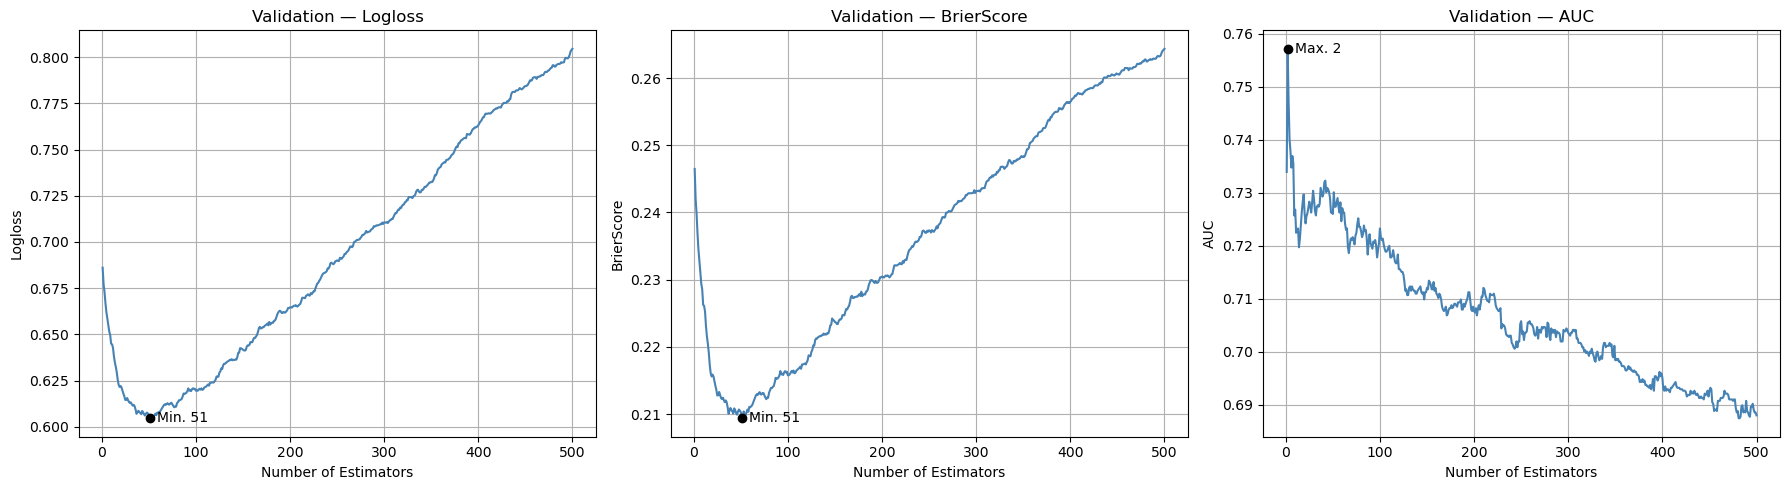

In [17]:
# Fine-tune number of estimators first

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Logloss', 'BrierScore', 'AUC']

for ax, metric in zip(axes, metrics):
    cb = CatBoostClassifier(n_estimators=500, random_state=42, verbose=0, eval_metric=metric)
    cb.fit(X_tr, y_tr, eval_set=(X_val, y_val))

    vals = cb.get_evals_result()['validation'][metric]
    n_iters = np.arange(1, len(vals) + 1)

    best_n = int(np.argmax(vals) if metric == 'AUC' else np.argmin(vals)) + 1
    best_val = vals[best_n - 1]

    ax.plot(n_iters, vals, color='steelblue', linewidth=1.5)
    ax.scatter([best_n], [best_val], color='black', zorder=5)
    ax.text(best_n + 8, best_val, f'Max. {best_n}' if metric == 'AUC' else f'Min. {best_n}', va='center', fontsize=10)
    ax.set_xlabel('Number of Estimators')
    ax.set_ylabel(metric)
    ax.set_title(f'Validation — {metric}')
    ax.grid(True)

    print(f"{metric:12s} — optimal n_estimators: {best_n:4d}  |  val {metric}: {best_val:.4f}")

print(f"AUC at 51 estimators: {vals[50]:.4f}")

plt.tight_layout()
plt.show()


Logloss      — optimal n_estimators:  119  |  mean val Logloss: 0.5861
BrierScore   — optimal n_estimators:  111  |  mean val BrierScore: 0.2009
AUC          — optimal n_estimators:  111  |  mean val AUC: 0.7532


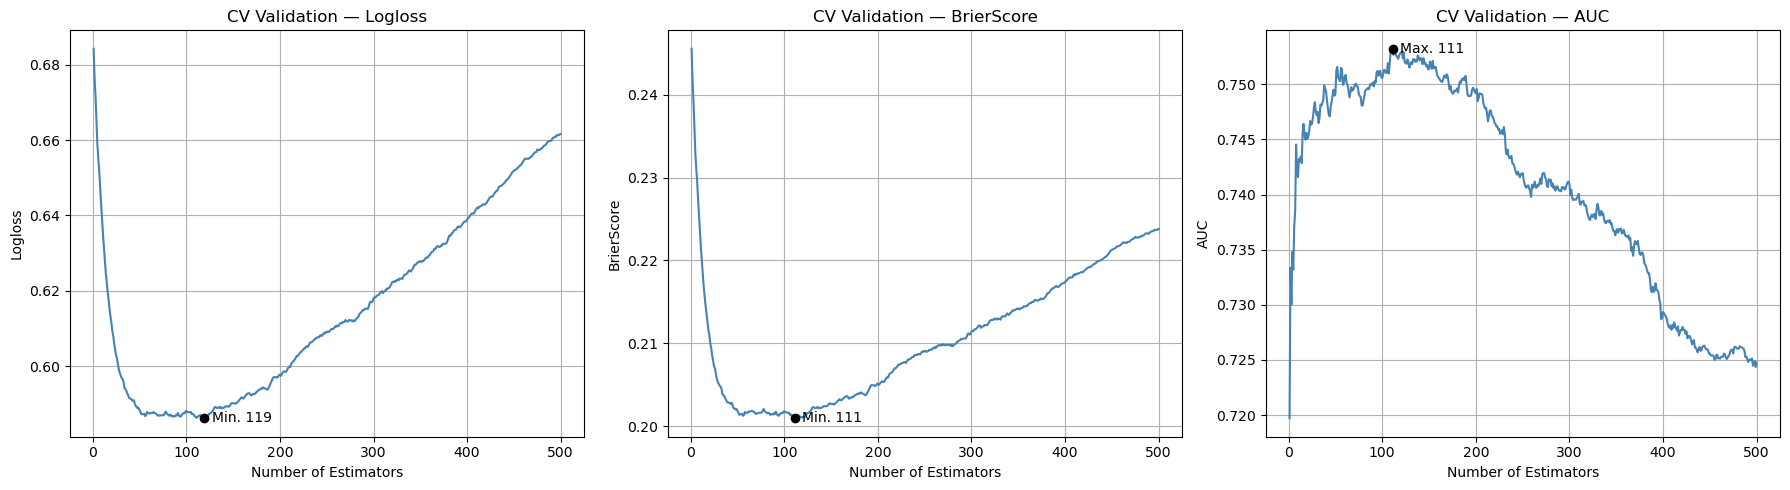

BrierScore at 119 estimators: 0.2010
AUC at 119 estimators: 0.7528


In [19]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['Logloss', 'BrierScore', 'AUC']
n_estimators = 500

cv_curves = {m: [] for m in metrics}

for metric in metrics:
    for train_idx, val_idx in kf.split(X_train_clean):
        X_tr_cv, X_val_cv = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(n_estimators=n_estimators, random_state=42, verbose=0, eval_metric=metric)
        cb.fit(X_tr_cv, y_tr_cv, eval_set=(X_val_cv, y_val_cv))
        cv_curves[metric].append(cb.get_evals_result()['validation'][metric])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    mean_curve = np.mean(cv_curves[metric], axis=0)
    n_iters = np.arange(1, len(mean_curve) + 1)
    best_n = int(np.argmax(mean_curve) if metric == 'AUC' else np.argmin(mean_curve)) + 1
    best_val = mean_curve[best_n - 1]

    ax.plot(n_iters, mean_curve, color='steelblue', linewidth=1.5)
    ax.scatter([best_n], [best_val], color='black', zorder=5)
    ax.text(best_n + 8, best_val, f'{"Max" if metric == "AUC" else "Min"}. {best_n}', va='center', fontsize=10)
    ax.set_xlabel('Number of Estimators')
    ax.set_ylabel(metric)
    ax.set_title(f'CV Validation — {metric}')
    ax.grid(True)

    print(f"{metric:12s} — optimal n_estimators: {best_n:4d}  |  mean val {metric}: {best_val:.4f}")

plt.tight_layout()
plt.show()

for metric in ['BrierScore', 'AUC']:
    mean_curve = np.mean(cv_curves[metric], axis=0)
    print(f"{metric} at 119 estimators: {mean_curve[118]:.4f}")



AUC           lr=0.01  — optimal n_estimators:  166  |  mean AUC: 0.7588
AUC           lr=0.03  — optimal n_estimators:   87  |  mean AUC: 0.7587
AUC           lr=0.05  — optimal n_estimators:   73  |  mean AUC: 0.7512
AUC           lr=0.10  — optimal n_estimators:   34  |  mean AUC: 0.7567
AUC           lr=0.30  — optimal n_estimators:    8  |  mean AUC: 0.7465

Logloss       lr=0.01  — optimal n_estimators:  310  |  mean Logloss: 0.5782
Logloss       lr=0.03  — optimal n_estimators:  115  |  mean Logloss: 0.5772
Logloss       lr=0.05  — optimal n_estimators:   71  |  mean Logloss: 0.5854
Logloss       lr=0.10  — optimal n_estimators:   34  |  mean Logloss: 0.5813
Logloss       lr=0.30  — optimal n_estimators:    8  |  mean Logloss: 0.5862

BrierScore    lr=0.01  — optimal n_estimators:  310  |  mean BrierScore: 0.1980
BrierScore    lr=0.03  — optimal n_estimators:  115  |  mean BrierScore: 0.1978
BrierScore    lr=0.05  — optimal n_estimators:   47  |  mean BrierScore: 0.2012
BrierSco

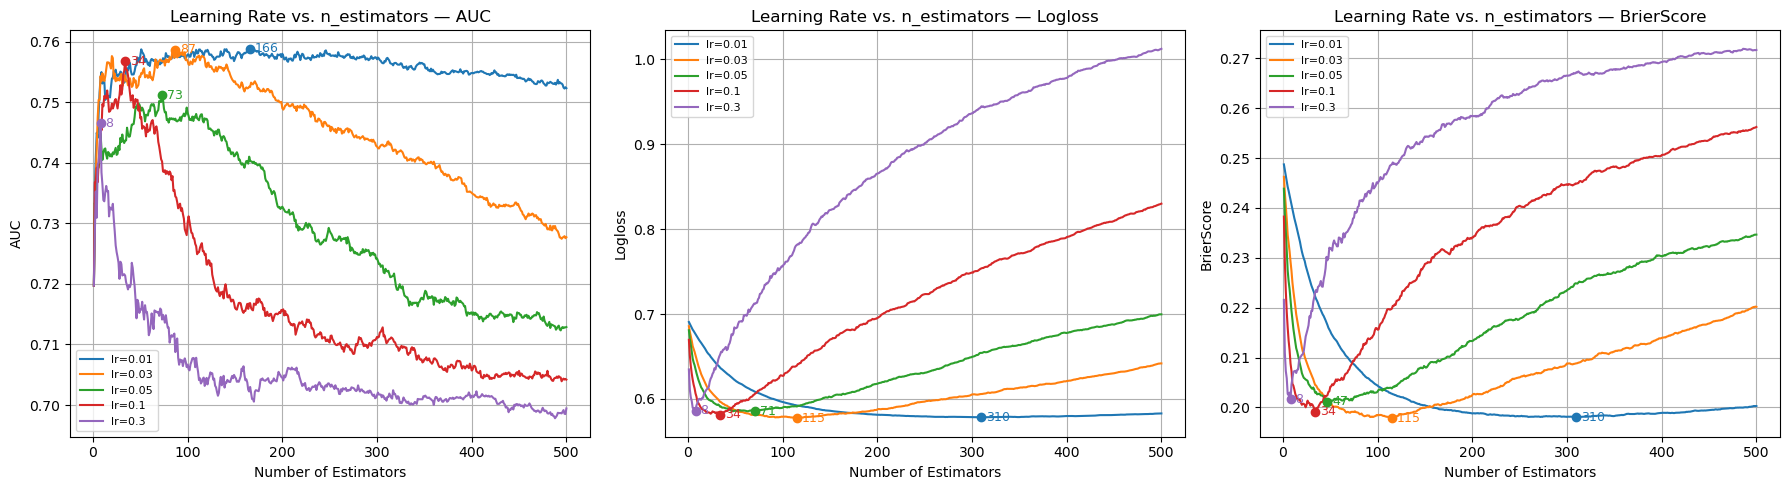

In [23]:
# Joint tuning of learning_rate and n_estimators.
#  We fix each learning rate, let CatBoost train up to 500 estimators,
# and track AUC, Logloss, and BrierScore at each iteration via 5-fold CV. The peak/trough of
# each curve tells us the optimal n_estimators for that learning rate.

learning_rates = [0.01, 0.03, 0.05, 0.1, 0.3]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
metrics = ['AUC', 'Logloss', 'BrierScore']
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store mean curve (across folds) for each learning rate and metric
lr_curves = {m: {} for m in metrics}

for lr in learning_rates:
    fold_curves = {m: [] for m in metrics}
    for train_idx, val_idx in kf.split(X_train_clean):
        X_tr_cv, X_val_cv = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Fit once per metric since CatBoost tracks one eval_metric at a time
        for metric in metrics:
            cb = CatBoostClassifier(
                n_estimators=500,
                learning_rate=lr,
                random_state=42,
                verbose=0,
                eval_metric=metric,
            )
            cb.fit(X_tr_cv, y_tr_cv, eval_set=(X_val_cv, y_val_cv))
            fold_curves[metric].append(cb.get_evals_result()['validation'][metric])

    # Average across folds for each metric
    for metric in metrics:
        lr_curves[metric][lr] = np.mean(fold_curves[metric], axis=0)

# One subplot per metric, all learning rates on the same plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    higher_is_better = metric == 'AUC'

    for lr, color in zip(learning_rates, colors):
        curve = lr_curves[metric][lr]
        n_iters = np.arange(1, len(curve) + 1)
        best_n = int(np.argmax(curve) if higher_is_better else np.argmin(curve)) + 1
        best_val = curve[best_n - 1]

        ax.plot(n_iters, curve, color=color, linewidth=1.5, label=f'lr={lr}')
        ax.scatter([best_n], [best_val], color=color, zorder=5)
        ax.text(best_n + 5, best_val, f'{best_n}', va='center', fontsize=9, color=color)
        print(f"{metric:12s}  lr={lr:.2f}  — optimal n_estimators: {best_n:4d}  |  mean {metric}: {best_val:.4f}")

    ax.set_xlabel('Number of Estimators')
    ax.set_ylabel(metric)
    ax.set_title(f'Learning Rate vs. n_estimators — {metric}')
    ax.legend(fontsize=8)
    ax.grid(True)
    print()

plt.tight_layout()
plt.show()


In [25]:
# Go with lr=0.3 and n_estimators=115.
# Compute mean AUC for those parameters
print(f"Mean AUC — lr=0.03, n_estimators=115: {lr_curves['AUC'][0.03][114]:.4f}")


Mean AUC — lr=0.03, n_estimators=115: 0.7577


depth=3  min_leaf= 1  — AUC: 0.7593  Logloss: 0.5799  Brier: 0.1984
depth=3  min_leaf= 5  — AUC: 0.7593  Logloss: 0.5799  Brier: 0.1984
depth=3  min_leaf=10  — AUC: 0.7593  Logloss: 0.5799  Brier: 0.1984
depth=3  min_leaf=20  — AUC: 0.7593  Logloss: 0.5799  Brier: 0.1984
depth=3  min_leaf=50  — AUC: 0.7593  Logloss: 0.5799  Brier: 0.1984
depth=4  min_leaf= 1  — AUC: 0.7574  Logloss: 0.5797  Brier: 0.1983
depth=4  min_leaf= 5  — AUC: 0.7574  Logloss: 0.5797  Brier: 0.1983
depth=4  min_leaf=10  — AUC: 0.7574  Logloss: 0.5797  Brier: 0.1983
depth=4  min_leaf=20  — AUC: 0.7574  Logloss: 0.5797  Brier: 0.1983
depth=4  min_leaf=50  — AUC: 0.7574  Logloss: 0.5797  Brier: 0.1983
depth=5  min_leaf= 1  — AUC: 0.7583  Logloss: 0.5784  Brier: 0.1980
depth=5  min_leaf= 5  — AUC: 0.7583  Logloss: 0.5784  Brier: 0.1980
depth=5  min_leaf=10  — AUC: 0.7583  Logloss: 0.5784  Brier: 0.1980
depth=5  min_leaf=20  — AUC: 0.7583  Logloss: 0.5784  Brier: 0.1980
depth=5  min_leaf=50  — AUC: 0.7583  Logloss: 0.

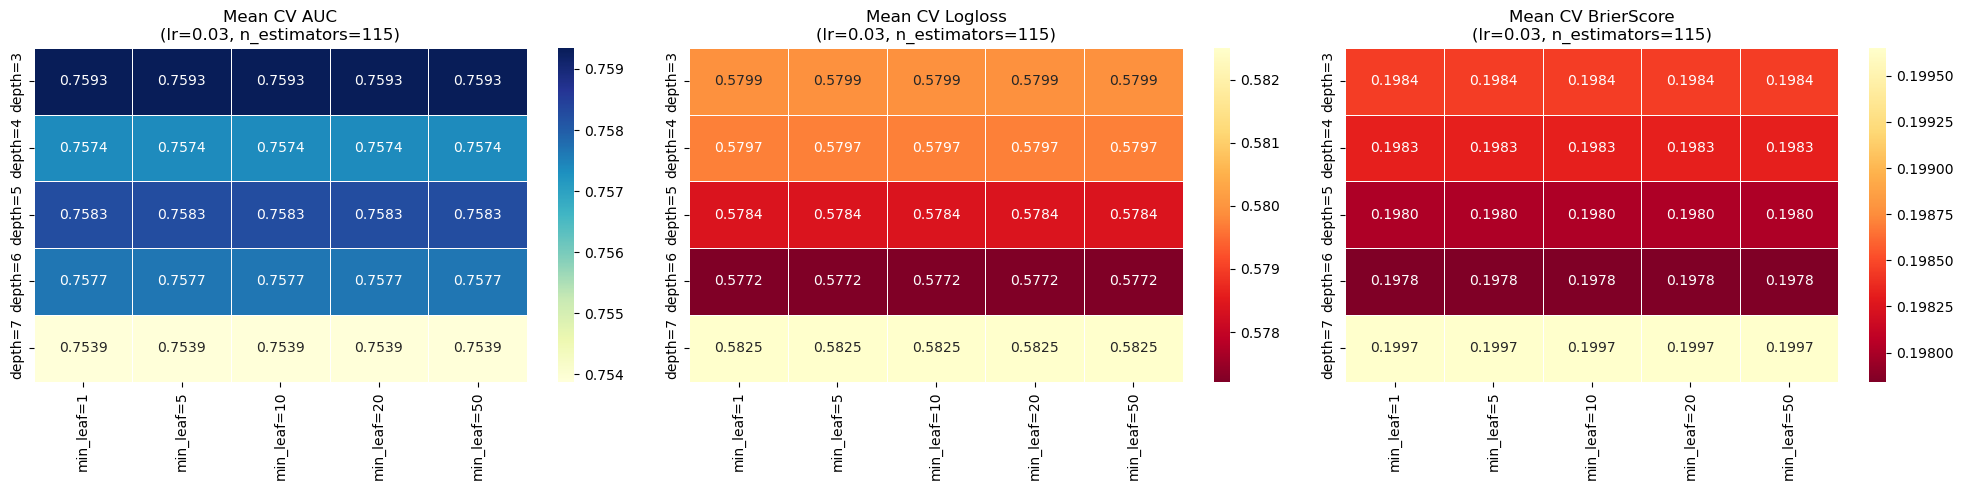

In [26]:

# Tune tree structure: depth and min_data_in_leaf.
# depth controls how complex each individual tree is (default=6); shallower trees = less overfitting.
# min_data_in_leaf sets the minimum samples required in a leaf, preventing overly specific splits.
# We fix lr=0.03 and n_estimators=115 from step 1, and grid search over both parameters.
# We evaluate all three metrics and show one heatmap per metric.

from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from itertools import product
import seaborn as sns

depths = [3, 4, 5, 6, 7]
min_data = [1, 5, 10, 20, 50]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_results = {m: {} for m in ['AUC', 'Logloss', 'BrierScore']}

for depth, min_leaf in product(depths, min_data):
    fold_auc, fold_logloss, fold_brier = [], [], []

    for train_idx, val_idx in kf.split(X_train_clean):
        X_tr_cv, X_val_cv = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(
            n_estimators=115,
            learning_rate=0.03,
            depth=depth,
            min_data_in_leaf=min_leaf,
            random_state=42,
            verbose=0,
        )
        cb.fit(X_tr_cv, y_tr_cv)
        proba = cb.predict_proba(X_val_cv)[:, 1]

        fold_auc.append(roc_auc_score(y_val_cv, proba))
        fold_logloss.append(log_loss(y_val_cv, proba))
        fold_brier.append(brier_score_loss(y_val_cv, proba))

    grid_results['AUC'][(depth, min_leaf)]        = np.mean(fold_auc)
    grid_results['Logloss'][(depth, min_leaf)]    = np.mean(fold_logloss)
    grid_results['BrierScore'][(depth, min_leaf)] = np.mean(fold_brier)
    print(f"depth={depth}  min_leaf={min_leaf:2d}  — AUC: {np.mean(fold_auc):.4f}  Logloss: {np.mean(fold_logloss):.4f}  Brier: {np.mean(fold_brier):.4f}")

# Plot one heatmap per metric
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# AUC: higher is better (YlGnBu — darker = better)
# Logloss and BrierScore: lower is better (YlOrRd_r — darker = better)
cmap_config = {'AUC': ('YlGnBu', False), 'Logloss': ('YlOrRd_r', False), 'BrierScore': ('YlOrRd_r', False)}

for ax, metric in zip(axes, ['AUC', 'Logloss', 'BrierScore']):
    matrix = pd.DataFrame(
        [[grid_results[metric][(d, m)] for m in min_data] for d in depths],
        index=[f'depth={d}' for d in depths],
        columns=[f'min_leaf={m}' for m in min_data]
    )
    cmap, _ = cmap_config[metric]
    sns.heatmap(matrix, annot=True, fmt='.4f', cmap=cmap, ax=ax, linewidths=0.5)
    ax.set_title(f'Mean CV {metric}\n(lr=0.03, n_estimators=115)')

    best = max(grid_results[metric], key=grid_results[metric].get) if metric == 'AUC' \
           else min(grid_results[metric], key=grid_results[metric].get)
    print(f"\nBest {metric}: depth={best[0]}, min_data_in_leaf={best[1]}  — {grid_results[metric][best]:.4f}")

plt.tight_layout()
plt.show()


Stick with depth=6, it wins on calibration metrics, and the AUC loss is not significant. The more important finding is that min_data_in_leaf can be dropped from further tuning 

l2=  0.1  rs=0.1  — AUC: 0.7250  Logloss: 0.6333  Brier: 0.2179
l2=  0.1  rs=0.5  — AUC: 0.7330  Logloss: 0.6095  Brier: 0.2112
l2=  0.1  rs=1.0  — AUC: 0.7398  Logloss: 0.5969  Brier: 0.2062
l2=  0.1  rs=3.0  — AUC: 0.7441  Logloss: 0.5925  Brier: 0.2038
l2=  0.1  rs=5.0  — AUC: 0.7488  Logloss: 0.5875  Brier: 0.2017
l2=  1.0  rs=0.1  — AUC: 0.7401  Logloss: 0.6027  Brier: 0.2086
l2=  1.0  rs=0.5  — AUC: 0.7451  Logloss: 0.5936  Brier: 0.2043
l2=  1.0  rs=1.0  — AUC: 0.7512  Logloss: 0.5853  Brier: 0.2012
l2=  1.0  rs=3.0  — AUC: 0.7535  Logloss: 0.5823  Brier: 0.1995
l2=  1.0  rs=5.0  — AUC: 0.7568  Logloss: 0.5821  Brier: 0.1993
l2=  3.0  rs=0.1  — AUC: 0.7406  Logloss: 0.5966  Brier: 0.2062
l2=  3.0  rs=0.5  — AUC: 0.7479  Logloss: 0.5881  Brier: 0.2024
l2=  3.0  rs=1.0  — AUC: 0.7577  Logloss: 0.5772  Brier: 0.1978
l2=  3.0  rs=3.0  — AUC: 0.7639  Logloss: 0.5748  Brier: 0.1962
l2=  3.0  rs=5.0  — AUC: 0.7554  Logloss: 0.5840  Brier: 0.2000
l2= 10.0  rs=0.1  — AUC: 0.7476  Logloss

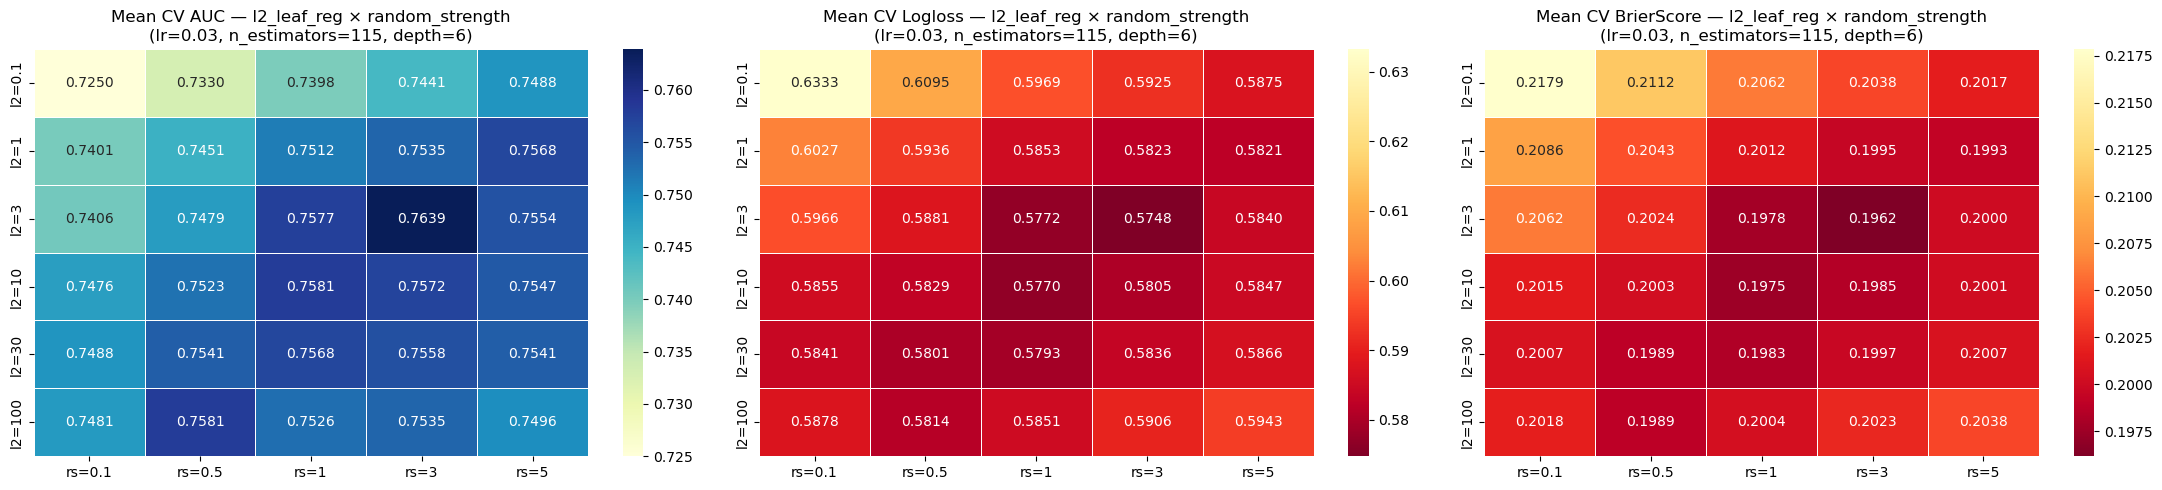

In [28]:
# Tune regularization: l2_leaf_reg and random_strength.
# l2_leaf_reg applies an L2 penalty on leaf weights, shrinking extreme predictions (default=3).
# random_strength adds noise to split scoring during tree building, preventing the model from
# overfitting to specific splits (default=1). Together they control how aggressively the model
# fits the training data. We fix lr=0.03, n_estimators=115, depth=6 from previous steps.

from itertools import product
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

l2_values = [0.1, 1, 3, 10, 30, 100]
rs_values  = [0.1, 0.5, 1, 3, 5]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

reg_results = {m: {} for m in ['AUC', 'Logloss', 'BrierScore']}

for l2, rs in product(l2_values, rs_values):
    fold_auc, fold_logloss, fold_brier = [], [], []

    for train_idx, val_idx in kf.split(X_train_clean):
        X_tr_cv, X_val_cv = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(
            n_estimators=115,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=l2,
            random_strength=rs,
            random_state=42,
            verbose=0,
        )
        cb.fit(X_tr_cv, y_tr_cv)
        proba = cb.predict_proba(X_val_cv)[:, 1]

        fold_auc.append(roc_auc_score(y_val_cv, proba))
        fold_logloss.append(log_loss(y_val_cv, proba))
        fold_brier.append(brier_score_loss(y_val_cv, proba))

    reg_results['AUC'][(l2, rs)]        = np.mean(fold_auc)
    reg_results['Logloss'][(l2, rs)]    = np.mean(fold_logloss)
    reg_results['BrierScore'][(l2, rs)] = np.mean(fold_brier)
    print(f"l2={l2:5.1f}  rs={rs:.1f}  — AUC: {np.mean(fold_auc):.4f}  Logloss: {np.mean(fold_logloss):.4f}  Brier: {np.mean(fold_brier):.4f}")

# Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
cmap_config = {'AUC': 'YlGnBu', 'Logloss': 'YlOrRd_r', 'BrierScore': 'YlOrRd_r'}

for ax, metric in zip(axes, ['AUC', 'Logloss', 'BrierScore']):
    matrix = pd.DataFrame(
        [[reg_results[metric][(l2, rs)] for rs in rs_values] for l2 in l2_values],
        index=[f'l2={l2}' for l2 in l2_values],
        columns=[f'rs={rs}' for rs in rs_values]
    )
    sns.heatmap(matrix, annot=True, fmt='.4f', cmap=cmap_config[metric], ax=ax, linewidths=0.5)
    ax.set_title(f'Mean CV {metric} — l2_leaf_reg × random_strength\n(lr=0.03, n_estimators=115, depth=6)')

    best = max(reg_results[metric], key=reg_results[metric].get) if metric == 'AUC' \
           else min(reg_results[metric], key=reg_results[metric].get)
    print(f"\nBest {metric}: l2_leaf_reg={best[0]}, random_strength={best[1]}  — {reg_results[metric][best]:.4f}")

plt.tight_layout()
plt.show()


Consistent across three metrics. Choose l2=3, rs=3

sub=0.5  col=0.5  — AUC: 0.7447  Logloss: 0.5902  Brier: 0.2027
sub=0.5  col=0.6  — AUC: 0.7517  Logloss: 0.5842  Brier: 0.2002
sub=0.5  col=0.7  — AUC: 0.7446  Logloss: 0.5902  Brier: 0.2027
sub=0.5  col=0.8  — AUC: 0.7567  Logloss: 0.5833  Brier: 0.1996
sub=0.5  col=0.9  — AUC: 0.7515  Logloss: 0.5879  Brier: 0.2015
sub=0.5  col=1.0  — AUC: 0.7548  Logloss: 0.5832  Brier: 0.1997
sub=0.6  col=0.5  — AUC: 0.7486  Logloss: 0.5887  Brier: 0.2023
sub=0.6  col=0.6  — AUC: 0.7528  Logloss: 0.5840  Brier: 0.2001
sub=0.6  col=0.7  — AUC: 0.7483  Logloss: 0.5883  Brier: 0.2020
sub=0.6  col=0.8  — AUC: 0.7551  Logloss: 0.5835  Brier: 0.2000
sub=0.6  col=0.9  — AUC: 0.7526  Logloss: 0.5844  Brier: 0.2003
sub=0.6  col=1.0  — AUC: 0.7539  Logloss: 0.5833  Brier: 0.2000
sub=0.7  col=0.5  — AUC: 0.7528  Logloss: 0.5840  Brier: 0.2004
sub=0.7  col=0.6  — AUC: 0.7552  Logloss: 0.5828  Brier: 0.1995
sub=0.7  col=0.7  — AUC: 0.7449  Logloss: 0.5881  Brier: 0.2023
sub=0.7  col=0.8  — AUC: 0.7556  Logloss

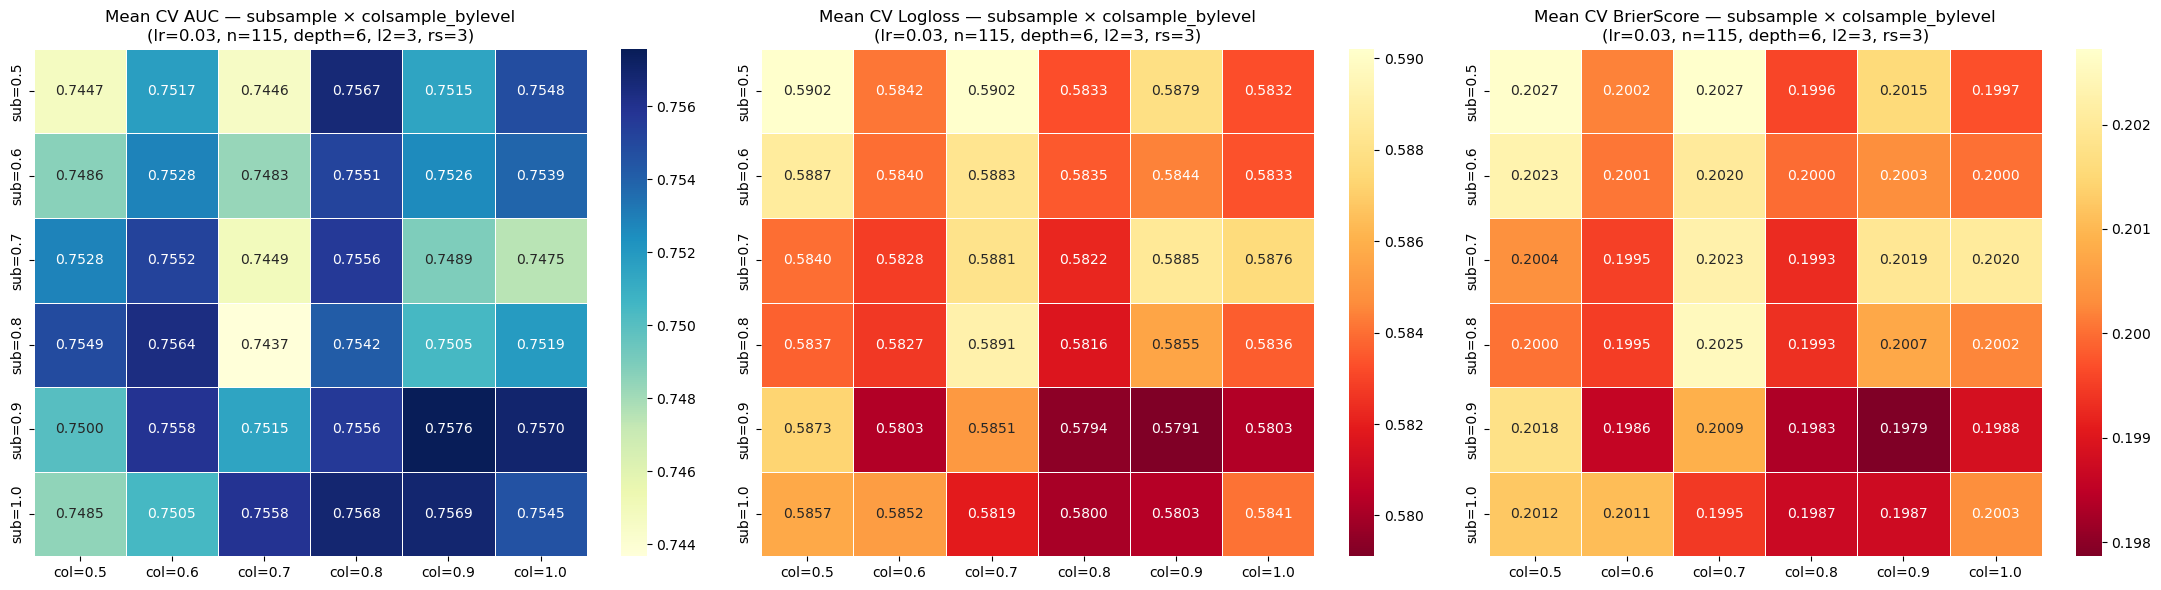

In [29]:
# Tune sampling: subsample and colsample_bylevel.
# subsample controls the fraction of training rows used to build each tree (default=1.0 in CatBoost
# with Bayesian bootstrap). Lower values add randomness and reduce overfitting.
# colsample_bylevel controls the fraction of features considered at each tree level (default=1.0).
# Lower values further decorrelate trees, similar to Random Forest logic.
# We fix all previous best params: lr=0.03, n_estimators=115, depth=6, l2=3, random_strength=3.

subsample_values    = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
colsample_values    = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

sampling_results = {m: {} for m in ['AUC', 'Logloss', 'BrierScore']}

for sub, col in product(subsample_values, colsample_values):
    fold_auc, fold_logloss, fold_brier = [], [], []

    for train_idx, val_idx in kf.split(X_train_clean):
        X_tr_cv, X_val_cv = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(
            n_estimators=115,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=3,
            random_strength=3,
            subsample=sub,
            colsample_bylevel=col,
            bootstrap_type='Bernoulli',  # required to enable subsample in CatBoost
            random_state=42,
            verbose=0,
        )
        cb.fit(X_tr_cv, y_tr_cv)
        proba = cb.predict_proba(X_val_cv)[:, 1]

        fold_auc.append(roc_auc_score(y_val_cv, proba))
        fold_logloss.append(log_loss(y_val_cv, proba))
        fold_brier.append(brier_score_loss(y_val_cv, proba))

    sampling_results['AUC'][(sub, col)]        = np.mean(fold_auc)
    sampling_results['Logloss'][(sub, col)]    = np.mean(fold_logloss)
    sampling_results['BrierScore'][(sub, col)] = np.mean(fold_brier)
    print(f"sub={sub:.1f}  col={col:.1f}  — AUC: {np.mean(fold_auc):.4f}  Logloss: {np.mean(fold_logloss):.4f}  Brier: {np.mean(fold_brier):.4f}")

# Heatmaps — one per metric
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
cmap_config = {'AUC': 'YlGnBu', 'Logloss': 'YlOrRd_r', 'BrierScore': 'YlOrRd_r'}

for ax, metric in zip(axes, ['AUC', 'Logloss', 'BrierScore']):
    matrix = pd.DataFrame(
        [[sampling_results[metric][(sub, col)] for col in colsample_values] for sub in subsample_values],
        index=[f'sub={s}' for s in subsample_values],
        columns=[f'col={c}' for c in colsample_values]
    )
    sns.heatmap(matrix, annot=True, fmt='.4f', cmap=cmap_config[metric], ax=ax, linewidths=0.5)
    ax.set_title(f'Mean CV {metric} — subsample × colsample_bylevel\n(lr=0.03, n=115, depth=6, l2=3, rs=3)')

    best = max(sampling_results[metric], key=sampling_results[metric].get) if metric == 'AUC' \
           else min(sampling_results[metric], key=sampling_results[metric].get)
    print(f"\nBest {metric}: subsample={best[0]}, colsample_bylevel={best[1]}  — {sampling_results[metric][best]:.4f}")

plt.tight_layout()
plt.show()


Sampling did not help. Undoing this is not the same as setting back to default because of the bootstrap_type='Bernoulli' technicality.

AUC           lr=0.005  — optimal n_estimators:   113  |  AUC: 0.7592
AUC           lr=0.010  — optimal n_estimators:   322  |  AUC: 0.7591
AUC           lr=0.020  — optimal n_estimators:   105  |  AUC: 0.7582
AUC           lr=0.030  — optimal n_estimators:   132  |  AUC: 0.7661

Logloss       lr=0.005  — optimal n_estimators:   884  |  Logloss: 0.5787
Logloss       lr=0.010  — optimal n_estimators:   526  |  Logloss: 0.5782
Logloss       lr=0.020  — optimal n_estimators:   236  |  Logloss: 0.5805
Logloss       lr=0.030  — optimal n_estimators:   137  |  Logloss: 0.5737

BrierScore    lr=0.005  — optimal n_estimators:   884  |  BrierScore: 0.1981
BrierScore    lr=0.010  — optimal n_estimators:   526  |  BrierScore: 0.1981
BrierScore    lr=0.020  — optimal n_estimators:   235  |  BrierScore: 0.1990
BrierScore    lr=0.030  — optimal n_estimators:   137  |  BrierScore: 0.1959



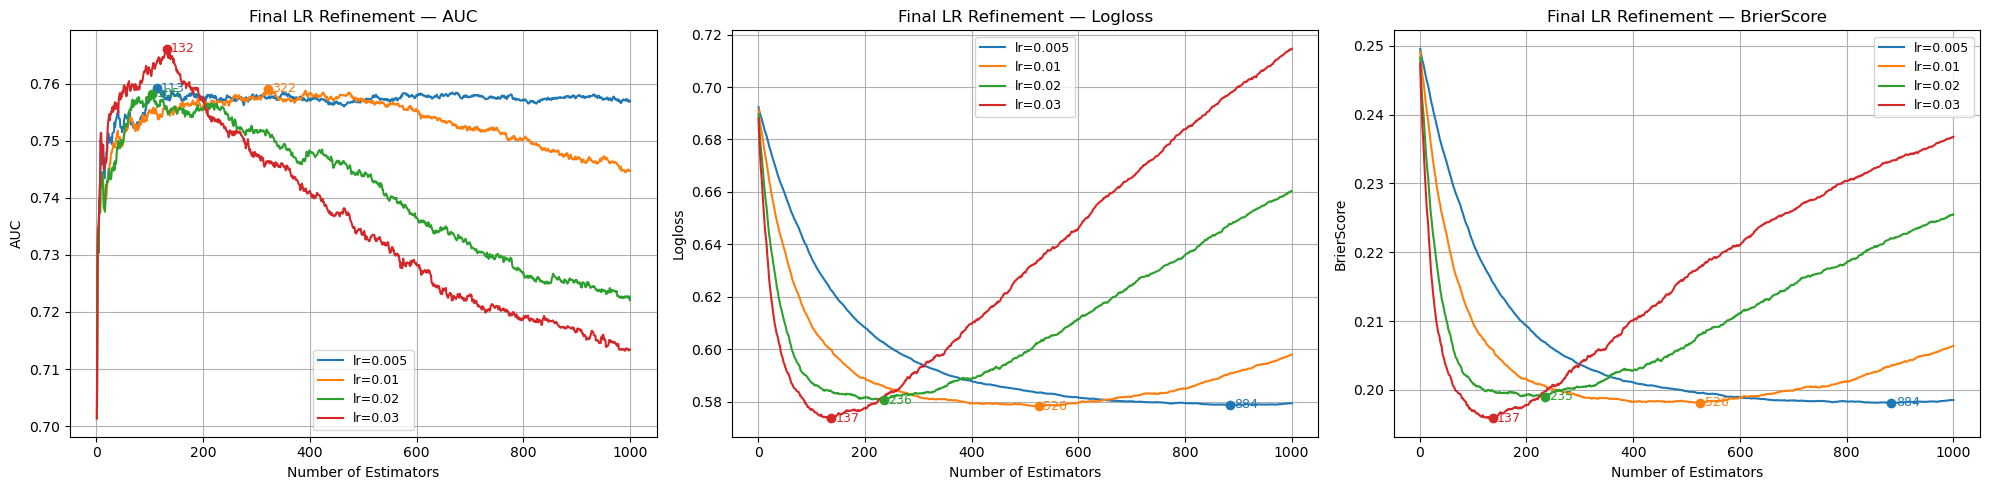

In [ ]:
# Final learning rate refinement.
# Now that all structural parameters are fixed, we lower the learning rate and let the model
# train for more estimators. A lower learning rate makes smaller, more cautious updates at each
# step — this often squeezes out the last bit of performance at the cost of more trees.
# We test rates below our current lr=0.03, running up to 1000 estimators to give slow learners
# enough room to converge. We use the same CV curve approach as step 1 for direct comparison.

learning_rates_final = [0.005, 0.01, 0.02, 0.03]
colors = ['#1f77b4', "#7e756c", '#2ca02c', '#d62728']
metrics = ['AUC', 'Logloss', 'BrierScore']
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_curves_final = {m: {} for m in metrics}

for lr in learning_rates_final:
    fold_curves = {m: [] for m in metrics}
    for train_idx, val_idx in kf.split(X_train_clean):
        X_tr_cv, X_val_cv = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Fit once per metric tracking validation curve at each iteration
        for metric in metrics:
            cb = CatBoostClassifier(
                n_estimators=1000,
                learning_rate=lr,
                depth=6,
                l2_leaf_reg=3,
                random_strength=3,
                random_state=42,
                verbose=0,
                eval_metric=metric,
            )
            cb.fit(X_tr_cv, y_tr_cv, eval_set=(X_val_cv, y_val_cv))
            fold_curves[metric].append(cb.get_evals_result()['validation'][metric])

    # Average across folds
    for metric in metrics:
        lr_curves_final[metric][lr] = np.mean(fold_curves[metric], axis=0)

# One subplot per metric, all learning rates on the same plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, metric in zip(axes, metrics):
    higher_is_better = metric == 'AUC'

    for lr, color in zip(learning_rates_final, colors):
        curve = lr_curves_final[metric][lr]
        n_iters = np.arange(1, len(curve) + 1)
        best_n = int(np.argmax(curve) if higher_is_better else np.argmin(curve)) + 1
        best_val = curve[best_n - 1]

        ax.plot(n_iters, curve, color=color, linewidth=1.5, label=f'lr={lr}')
        ax.scatter([best_n], [best_val], color=color, zorder=5)
        ax.text(best_n + 8, best_val, f'{best_n}', va='center', fontsize=9, color=color)
        print(f"{metric:12s}  lr={lr:.3f}  — optimal n_estimators: {best_n:5d}  |  {metric}: {best_val:.4f}")

    ax.set_xlabel('Number of Estimators')
    ax.set_ylabel(metric)
    ax.set_title(f'Final LR Refinement — {metric}')
    ax.legend(fontsize=9)
    ax.grid(True)
    print()

plt.tight_layout()
plt.show()


## Feature Selection

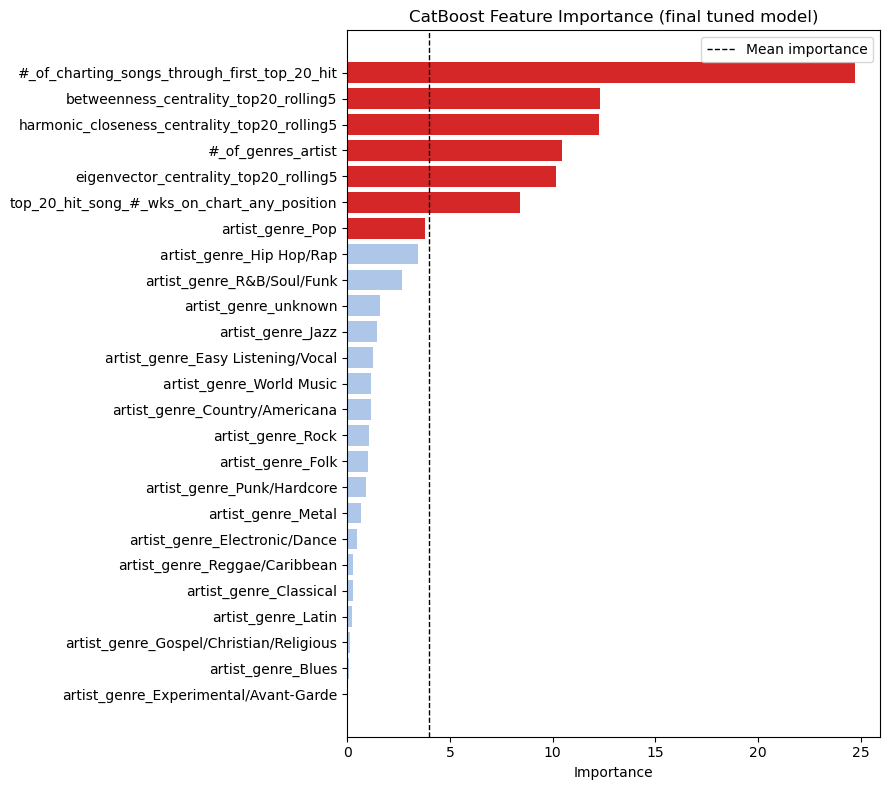

Top 10 features:
                                     Feature  Importance
#_of_charting_songs_through_first_top_20_hit   24.710452
       betweenness_centrality_top20_rolling5   12.293278
harmonic_closeness_centrality_top20_rolling5   12.259786
                          #_of_genres_artist   10.445811
       eigenvector_centrality_top20_rolling5   10.181642
 top_20_hit_song_#_wks_on_chart_any_position    8.392908
                            artist_genre_Pop    3.804137
                    artist_genre_Hip Hop/Rap    3.450405
                  artist_genre_R&B/Soul/Funk    2.649501
                        artist_genre_unknown    1.607883

Bottom 10 features (candidates for removal):
                                Feature  Importance
  artist_genre_Experimental/Avant-Garde    0.049436
                     artist_genre_Blues    0.077475
artist_genre_Gospel/Christian/Religious    0.144190
                     artist_genre_Latin    0.250497
                 artist_genre_Classical    0.27498

In [31]:
# Feature importance: fit the final tuned model on the full training set, then extract
# how much each feature contributed to the model's predictions.
# CatBoost uses "PredictionValuesChange" by default — measures how much each feature
# shifts the predicted value on average across all trees.

cb_final = CatBoostClassifier(
    n_estimators=132,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_strength=3,
    random_state=42,
    verbose=0,
)
cb_final.fit(X_train_clean, y_train)

# Extract and sort feature importances
feat_imp = cb_final.get_feature_importance(prettified=True)
feat_imp.columns = ['Feature', 'Importance']
feat_imp = feat_imp.sort_values('Importance', ascending=True)

# Bar chart — horizontal for readability with many features
fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#d62728' if imp >= feat_imp['Importance'].quantile(0.75) else '#aec7e8'
          for imp in feat_imp['Importance']]
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors)
ax.axvline(feat_imp['Importance'].mean(), color='black', linestyle='--', linewidth=1, label='Mean importance')
ax.set_xlabel('Importance')
ax.set_title('CatBoost Feature Importance (final tuned model)')
ax.legend()
plt.tight_layout()
plt.show()

# Print top and bottom features
print("Top 10 features:")
print(feat_imp.tail(10).sort_values('Importance', ascending=False).to_string(index=False))
print("\nBottom 10 features (candidates for removal):")
print(feat_imp.head(10).to_string(index=False))


Baseline              Train AUC: 0.9550  CV AUC: 0.7554  Gap: 0.1996
Step 1 (lr+n)         Train AUC: 0.9221  CV AUC: 0.7577  Gap: 0.1645
Step 2 (depth)        Train AUC: 0.9221  CV AUC: 0.7577  Gap: 0.1645
Step 3 (reg)          Train AUC: 0.8907  CV AUC: 0.7639  Gap: 0.1268
Step 5 (final)        Train AUC: 0.8993  CV AUC: 0.7661  Gap: 0.1332


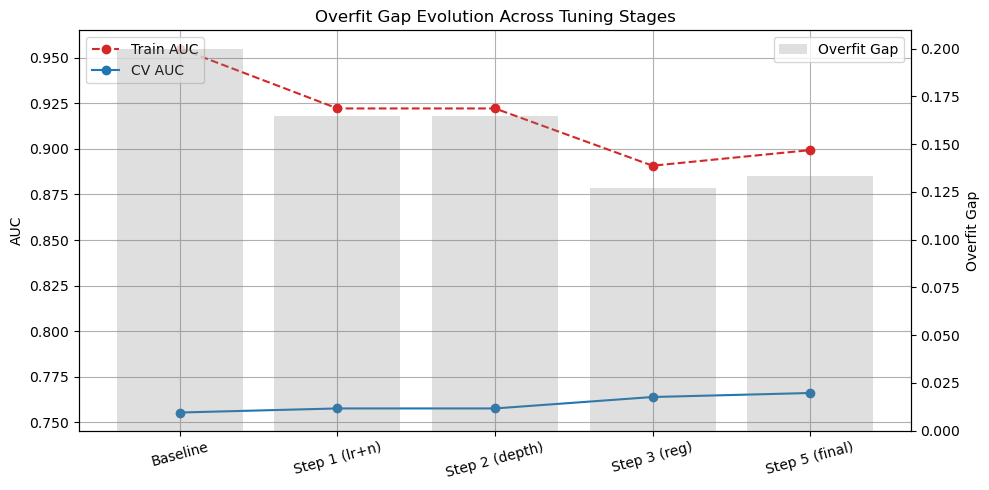

In [33]:
# Check how overfit gap has been doing. This should have been done alongside the other metrics
# Compute train AUC and CV AUC for each tuning stage to track overfit gap evolution

stages = {
    'Baseline':       CatBoostClassifier(n_estimators=100, random_state=42, verbose=0),
    'Step 1 (lr+n)':  CatBoostClassifier(n_estimators=115, learning_rate=0.03, random_state=42, verbose=0),
    'Step 2 (depth)': CatBoostClassifier(n_estimators=115, learning_rate=0.03, depth=6, random_state=42, verbose=0),
    'Step 3 (reg)':   CatBoostClassifier(n_estimators=115, learning_rate=0.03, depth=6, l2_leaf_reg=3, random_strength=3, random_state=42, verbose=0),
    'Step 5 (final)': CatBoostClassifier(n_estimators=132, learning_rate=0.03, depth=6, l2_leaf_reg=3, random_strength=3, random_state=42, verbose=0),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
gap_results = []

for name, model in stages.items():
    fold_train_auc, fold_val_auc = [], []
    for train_idx, val_idx in kf.split(X_train_clean):
        X_tr_cv, X_val_cv = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr_cv, y_tr_cv)
        fold_train_auc.append(roc_auc_score(y_tr_cv, model.predict_proba(X_tr_cv)[:, 1]))
        fold_val_auc.append(roc_auc_score(y_val_cv, model.predict_proba(X_val_cv)[:, 1]))

    train_auc = np.mean(fold_train_auc)
    val_auc   = np.mean(fold_val_auc)
    gap       = train_auc - val_auc
    gap_results.append({'Stage': name, 'Train AUC': train_auc, 'CV AUC': val_auc, 'Overfit Gap': gap})
    print(f"{name:20s}  Train AUC: {train_auc:.4f}  CV AUC: {val_auc:.4f}  Gap: {gap:.4f}")

df_gap = pd.DataFrame(gap_results).set_index('Stage')

# Plot train AUC, CV AUC, and gap across stages
fig, ax1 = plt.subplots(figsize=(10, 5))
x = range(len(df_gap))

ax1.plot(x, df_gap['Train AUC'], 'o--', color='#d62728', label='Train AUC')
ax1.plot(x, df_gap['CV AUC'],    'o-',  color='#1f77b4', label='CV AUC')
ax1.set_ylabel('AUC')
ax1.set_xticks(x)
ax1.set_xticklabels(df_gap.index, rotation=15)
ax1.legend(loc='upper left')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.bar(x, df_gap['Overfit Gap'], alpha=0.25, color='grey', label='Overfit Gap')
ax2.set_ylabel('Overfit Gap')
ax2.legend(loc='upper right')

ax1.set_title('Overfit Gap Evolution Across Tuning Stages')
plt.tight_layout()
plt.show()


n= 6  +[top_20_hit_song_#_wks_on_chart_any_posit]  AUC: 0.7547  Gap: 0.0794  Logloss: 0.5854  Brier: 0.2000
n= 7  +[artist_genre_Pop                        ]  AUC: 0.7525  Gap: 0.0847  Logloss: 0.5833  Brier: 0.1998
n= 8  +[artist_genre_Hip Hop/Rap                ]  AUC: 0.7541  Gap: 0.0889  Logloss: 0.5835  Brier: 0.1998
n= 9  +[artist_genre_R&B/Soul/Funk              ]  AUC: 0.7569  Gap: 0.0841  Logloss: 0.5840  Brier: 0.1998
n=10  +[artist_genre_unknown                    ]  AUC: 0.7527  Gap: 0.0893  Logloss: 0.5861  Brier: 0.2006
n=11  +[artist_genre_Jazz                       ]  AUC: 0.7560  Gap: 0.0881  Logloss: 0.5834  Brier: 0.1994
n=12  +[artist_genre_Easy Listening/Vocal       ]  AUC: 0.7552  Gap: 0.0886  Logloss: 0.5845  Brier: 0.1999
n=13  +[artist_genre_World Music                ]  AUC: 0.7553  Gap: 0.0848  Logloss: 0.5846  Brier: 0.1998
n=14  +[artist_genre_Country/Americana          ]  AUC: 0.7563  Gap: 0.0870  Logloss: 0.5835  Brier: 0.1995
n=15  +[artist_genre_Rock   

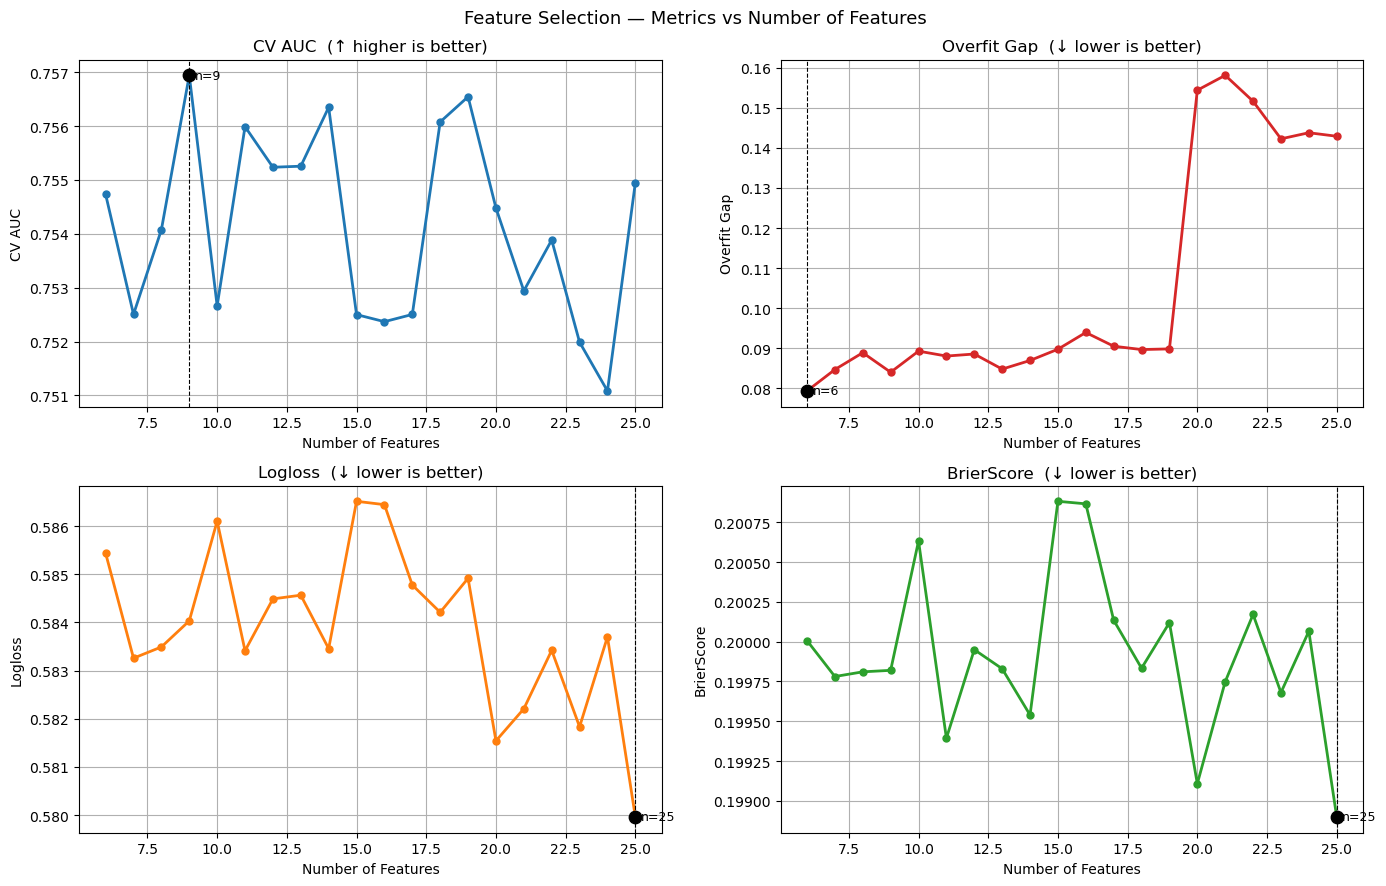

In [34]:
# Feature selection: start with the top 6 features (by CatBoost importance) and add one at a time.
# For each feature subset, we run 5-fold CV and track all 4 metrics.
# The plots show the point of diminishing returns — where adding more features stops helping.

# Feature order from importance (descending)
feature_order = feat_imp.sort_values('Importance', ascending=False)['Feature'].tolist()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
selection_results = []

for n_feats in range(6, len(feature_order) + 1):
    features_subset = feature_order[:n_feats]
    X_subset = X_train_clean[features_subset]

    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []

    for train_idx, val_idx in kf.split(X_subset):
        X_tr_cv, X_val_cv = X_subset.iloc[train_idx], X_subset.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(
            n_estimators=132,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=3,
            random_strength=3,
            random_state=42,
            verbose=0,
        )
        cb.fit(X_tr_cv, y_tr_cv)
        proba       = cb.predict_proba(X_val_cv)[:, 1]
        proba_train = cb.predict_proba(X_tr_cv)[:, 1]

        fold_val_auc.append(roc_auc_score(y_val_cv, proba))
        fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
        fold_logloss.append(log_loss(y_val_cv, proba))
        fold_brier.append(brier_score_loss(y_val_cv, proba))

    val_auc  = np.mean(fold_val_auc)
    train_auc = np.mean(fold_train_auc)
    selection_results.append({
        'n_features':  n_feats,
        'last_added':  feature_order[n_feats - 1],
        'CV AUC':      val_auc,
        'Train AUC':   train_auc,
        'Overfit Gap': train_auc - val_auc,
        'Logloss':     np.mean(fold_logloss),
        'BrierScore':  np.mean(fold_brier),
    })
    print(f"n={n_feats:2d}  +[{feature_order[n_feats-1][:40]:40s}]  AUC: {val_auc:.4f}  Gap: {train_auc - val_auc:.4f}  Logloss: {np.mean(fold_logloss):.4f}  Brier: {np.mean(fold_brier):.4f}")

df_sel = pd.DataFrame(selection_results).set_index('n_features')

# 4 subplots — one per metric, x-axis = number of features
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics_plot = [
    ('CV AUC',      '#1f77b4', 'higher'),
    ('Overfit Gap', '#d62728', 'lower'),
    ('Logloss',     '#ff7f0e', 'lower'),
    ('BrierScore',  '#2ca02c', 'lower'),
]

for ax, (metric, color, better) in zip(axes.flat, metrics_plot):
    ax.plot(df_sel.index, df_sel[metric], 'o-', color=color, linewidth=2, markersize=5)
    best_n = df_sel[metric].idxmax() if better == 'higher' else df_sel[metric].idxmin()
    best_val = df_sel[metric][best_n]
    ax.scatter([best_n], [best_val], color='black', zorder=5, s=80)
    ax.axvline(best_n, color='black', linestyle='--', linewidth=0.8)
    ax.text(best_n + 0.2, best_val, f'n={best_n}', fontsize=9, va='center')
    ax.set_xlabel('Number of Features')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}  ({"↑ higher" if better == "higher" else "↓ lower"} is better)')
    ax.grid(True)

plt.suptitle('Feature Selection — Metrics vs Number of Features', fontsize=13)
plt.tight_layout()
plt.show()


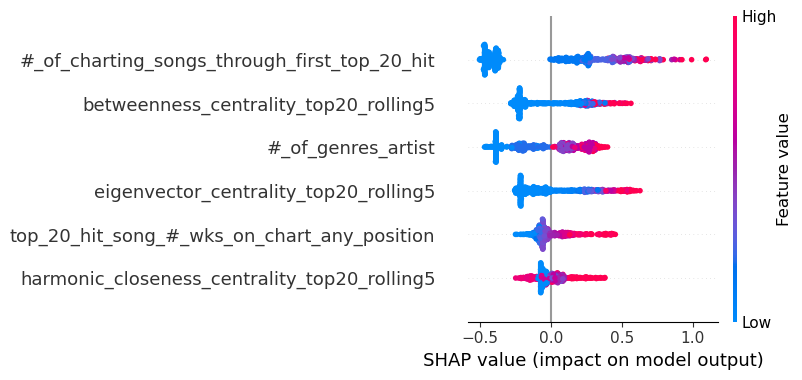

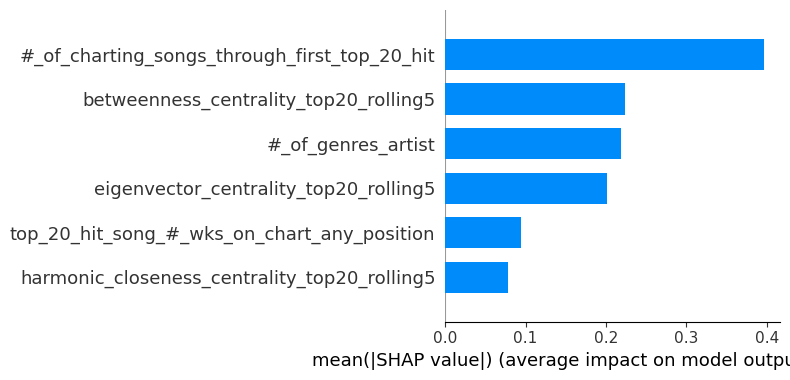

In [36]:
import shap

# Lock in the top 6 features
top6_features = feature_order[:6]
X_train_top6 = X_train_clean[top6_features]

# Fit final model on top 6 features
cb_top6 = CatBoostClassifier(
    n_estimators=132,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_strength=3,
    random_state=42,
    verbose=0,
)
cb_top6.fit(X_train_top6, y_train)

# Compute SHAP values — CatBoost has native SHAP support
explainer = shap.TreeExplainer(cb_top6)
shap_values = explainer.shap_values(X_train_top6)

# Beeswarm plot — each dot is one artist
# color = feature value (red=high, blue=low)
# x-axis = SHAP value: positive pushes toward hitmaker, negative pushes away
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_train_top6, show=True)

# Bar plot — mean absolute SHAP value per feature (simpler importance ranking)
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_train_top6, plot_type='bar', show=True)


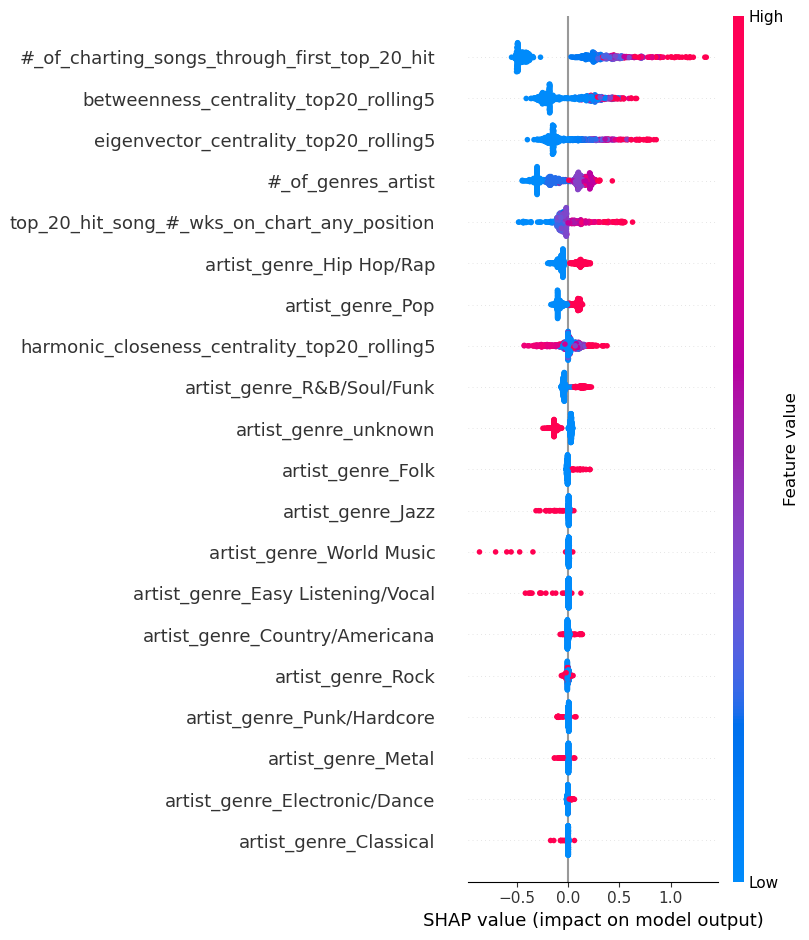

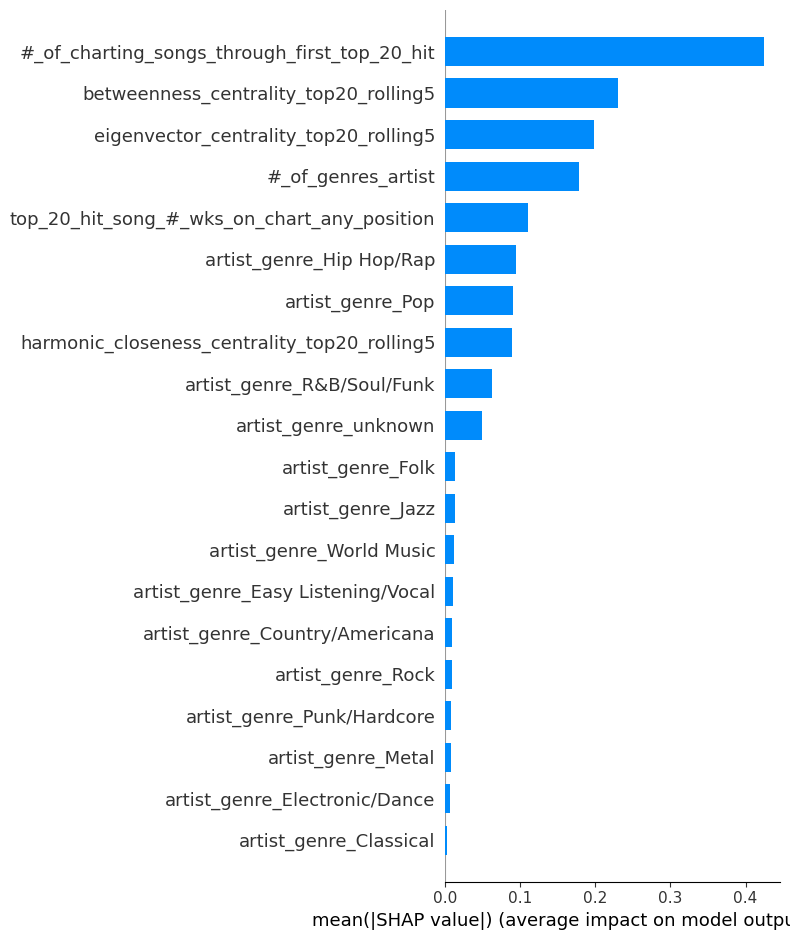

In [37]:
import shap

# Fit final model on all 25 features
cb_all = CatBoostClassifier(
    n_estimators=132,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_strength=3,
    random_state=42,
    verbose=0,
)
cb_all.fit(X_train_clean, y_train)

# Compute SHAP values
explainer_all = shap.TreeExplainer(cb_all)
shap_values_all = explainer_all.shap_values(X_train_clean)

# Beeswarm plot
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values_all, X_train_clean, show=True)

# Bar plot
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values_all, X_train_clean, plot_type='bar', show=True)


In [40]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []

for train_idx, val_idx in kf.split(X_train_top6):
    X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
    y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

    cb_top6.fit(X_tr_cv, y_tr_cv)
    proba       = cb_top6.predict_proba(X_val_cv)[:, 1]
    proba_train = cb_top6.predict_proba(X_tr_cv)[:, 1]

    fold_val_auc.append(roc_auc_score(y_val_cv, proba))
    fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
    fold_logloss.append(log_loss(y_val_cv, proba))
    fold_brier.append(brier_score_loss(y_val_cv, proba))

print(f"CV AUC:      {np.mean(fold_val_auc):.4f}")
print(f"Train AUC:   {np.mean(fold_train_auc):.4f}")
print(f"Overfit Gap: {np.mean(fold_train_auc) - np.mean(fold_val_auc):.4f}")
print(f"Logloss:     {np.mean(fold_logloss):.4f}")
print(f"BrierScore:  {np.mean(fold_brier):.4f}")


CV AUC:      0.7547
Train AUC:   0.8341
Overfit Gap: 0.0794
Logloss:     0.5854
BrierScore:  0.2000


depth=3  l2=  3  rs= 3  — AUC: 0.7504  Gap: 0.0426  Logloss: 0.5912  Brier: 0.2028
depth=3  l2=  3  rs= 5  — AUC: 0.7498  Gap: 0.0372  Logloss: 0.5938  Brier: 0.2037
depth=3  l2=  3  rs=10  — AUC: 0.7450  Gap: 0.0326  Logloss: 0.5986  Brier: 0.2056
depth=3  l2= 10  rs= 3  — AUC: 0.7512  Gap: 0.0328  Logloss: 0.5942  Brier: 0.2038
depth=3  l2= 10  rs= 5  — AUC: 0.7452  Gap: 0.0301  Logloss: 0.6002  Brier: 0.2063
depth=3  l2= 10  rs=10  — AUC: 0.7414  Gap: 0.0242  Logloss: 0.6047  Brier: 0.2081
depth=3  l2= 30  rs= 3  — AUC: 0.7456  Gap: 0.0278  Logloss: 0.6050  Brier: 0.2082
depth=3  l2= 30  rs= 5  — AUC: 0.7397  Gap: 0.0236  Logloss: 0.6116  Brier: 0.2111
depth=3  l2= 30  rs=10  — AUC: 0.7334  Gap: 0.0187  Logloss: 0.6168  Brier: 0.2134
depth=3  l2=100  rs= 3  — AUC: 0.7415  Gap: 0.0218  Logloss: 0.6272  Brier: 0.2179
depth=3  l2=100  rs= 5  — AUC: 0.7330  Gap: 0.0170  Logloss: 0.6333  Brier: 0.2208
depth=3  l2=100  rs=10  — AUC: 0.7250  Gap: 0.0131  Logloss: 0.6385  Brier: 0.2232
dept

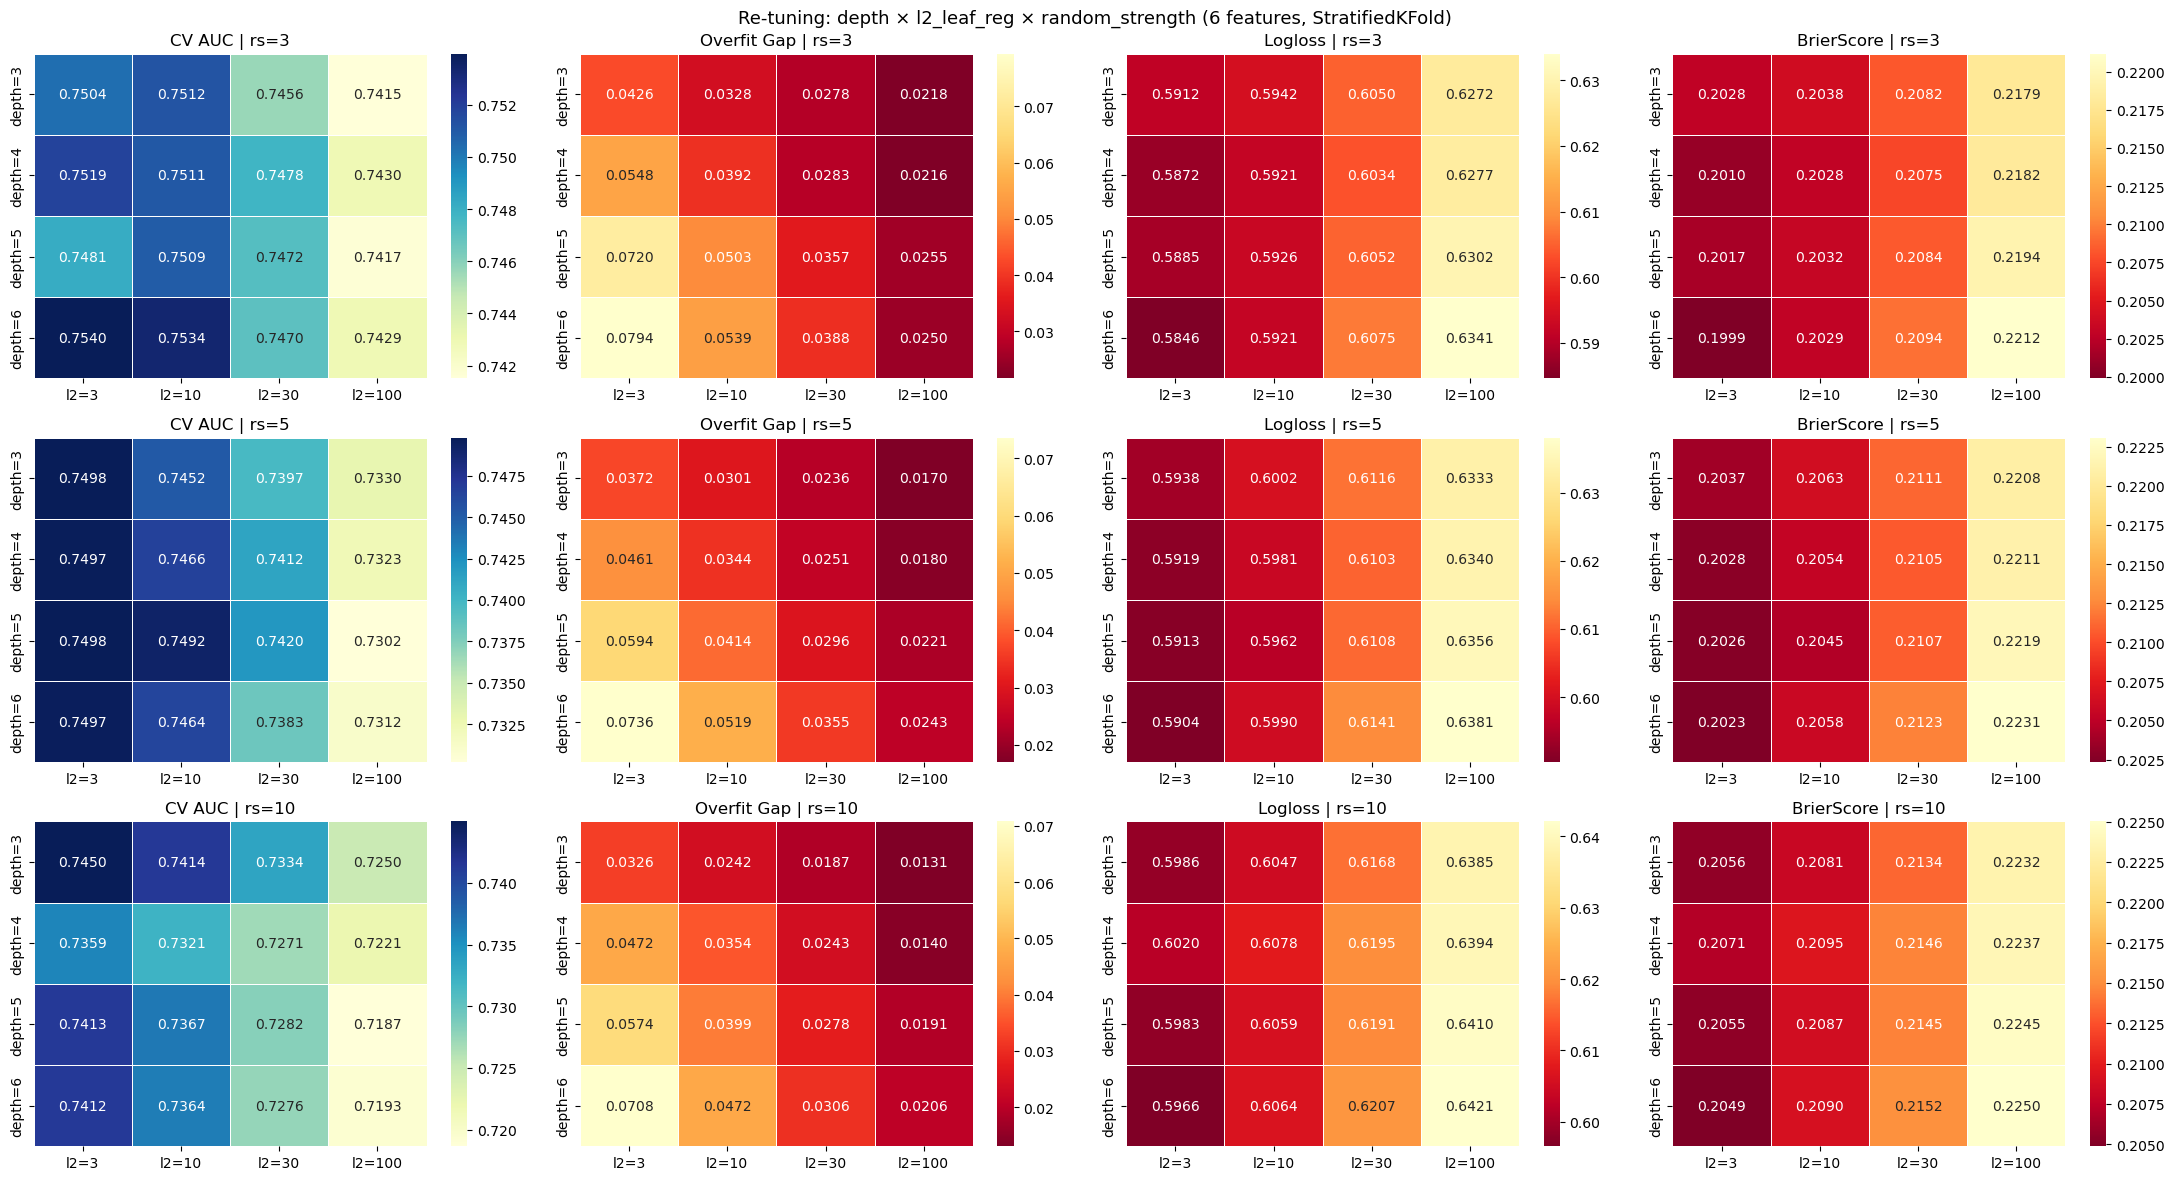


Best CV AUC:  depth=6, l2=3, rs=3  — AUC: 0.7540  Gap: 0.0794
Smallest Gap: depth=3, l2=100, rs=10  — AUC: 0.7250  Gap: 0.0131

--- StratifiedKFold vs KFold comparison (best config) ---
StratifiedKFold       CV AUC: 0.7540  Gap: 0.0794
KFold                 CV AUC: 0.7547  Gap: 0.0794


In [41]:
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from itertools import product
import seaborn as sns

# Re-tuning depth and regularization specifically for the 6-feature model.
# With fewer features, shallower trees and stronger regularization may generalize better.
# We also switch to StratifiedKFold to ensure each fold maintains the original class balance
# (57% non-hitmaker / 43% hitmaker), which matters for a dataset of only 759 artists.

depths    = [3, 4, 5, 6]
l2_values = [3, 10, 30, 100]
rs_values = [3, 5, 10]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf  = KFold(n_splits=5, shuffle=True, random_state=42)

retune_results = {m: {} for m in ['CV AUC', 'Overfit Gap', 'Logloss', 'BrierScore']}

for depth, l2, rs in product(depths, l2_values, rs_values):
    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []

    for train_idx, val_idx in skf.split(X_train_top6, y_train):
        X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(
            n_estimators=132,
            learning_rate=0.03,
            depth=depth,
            l2_leaf_reg=l2,
            random_strength=rs,
            random_state=42,
            verbose=0,
        )
        cb.fit(X_tr_cv, y_tr_cv)
        proba       = cb.predict_proba(X_val_cv)[:, 1]
        proba_train = cb.predict_proba(X_tr_cv)[:, 1]

        fold_val_auc.append(roc_auc_score(y_val_cv, proba))
        fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
        fold_logloss.append(log_loss(y_val_cv, proba))
        fold_brier.append(brier_score_loss(y_val_cv, proba))

    retune_results['CV AUC'][(depth, l2, rs)]      = np.mean(fold_val_auc)
    retune_results['Overfit Gap'][(depth, l2, rs)] = np.mean(fold_train_auc) - np.mean(fold_val_auc)
    retune_results['Logloss'][(depth, l2, rs)]     = np.mean(fold_logloss)
    retune_results['BrierScore'][(depth, l2, rs)]  = np.mean(fold_brier)
    print(f"depth={depth}  l2={l2:3d}  rs={rs:2d}  — AUC: {np.mean(fold_val_auc):.4f}  Gap: {np.mean(fold_train_auc)-np.mean(fold_val_auc):.4f}  Logloss: {np.mean(fold_logloss):.4f}  Brier: {np.mean(fold_brier):.4f}")

# One row of heatmaps per random_strength value, one column per metric
fig, axes = plt.subplots(len(rs_values), 4, figsize=(22, 4 * len(rs_values)))
cmap_config = {'CV AUC': 'YlGnBu', 'Overfit Gap': 'YlOrRd_r', 'Logloss': 'YlOrRd_r', 'BrierScore': 'YlOrRd_r'}

for row, rs in enumerate(rs_values):
    for col, metric in enumerate(['CV AUC', 'Overfit Gap', 'Logloss', 'BrierScore']):
        ax = axes[row, col]
        matrix = pd.DataFrame(
            [[retune_results[metric][(d, l2, rs)] for l2 in l2_values] for d in depths],
            index=[f'depth={d}' for d in depths],
            columns=[f'l2={l2}' for l2 in l2_values]
        )
        sns.heatmap(matrix, annot=True, fmt='.4f', cmap=cmap_config[metric], ax=ax, linewidths=0.5)
        ax.set_title(f'{metric} | rs={rs}')

plt.suptitle('Re-tuning: depth × l2_leaf_reg × random_strength (6 features, StratifiedKFold)', fontsize=13)
plt.tight_layout()
plt.show()

# Find best config across all combinations
best = max(retune_results['CV AUC'], key=retune_results['CV AUC'].get)
print(f"\nBest CV AUC:  depth={best[0]}, l2={best[1]}, rs={best[2]}  — AUC: {retune_results['CV AUC'][best]:.4f}  Gap: {retune_results['Overfit Gap'][best]:.4f}")
best_gap = min(retune_results['Overfit Gap'], key=retune_results['Overfit Gap'].get)
print(f"Smallest Gap: depth={best_gap[0]}, l2={best_gap[1]}, rs={best_gap[2]}  — AUC: {retune_results['CV AUC'][best_gap]:.4f}  Gap: {retune_results['Overfit Gap'][best_gap]:.4f}")

# Compare StratifiedKFold vs KFold for the best config
print("\n--- StratifiedKFold vs KFold comparison (best config) ---")
for cv_name, cv in [('StratifiedKFold', skf), ('KFold', kf)]:
    fold_train_auc, fold_val_auc = [], []
    for train_idx, val_idx in cv.split(X_train_top6, y_train):
        X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
        cb = CatBoostClassifier(n_estimators=132, learning_rate=0.03, depth=best[0],
                                l2_leaf_reg=best[1], random_strength=best[2], random_state=42, verbose=0)
        cb.fit(X_tr_cv, y_tr_cv)
        fold_val_auc.append(roc_auc_score(y_val_cv, cb.predict_proba(X_val_cv)[:, 1]))
        fold_train_auc.append(roc_auc_score(y_tr_cv, cb.predict_proba(X_tr_cv)[:, 1]))
    print(f"{cv_name:20s}  CV AUC: {np.mean(fold_val_auc):.4f}  Gap: {np.mean(fold_train_auc)-np.mean(fold_val_auc):.4f}")


AUC           lr=0.005  — optimal n_estimators:  1000  |  AUC: 0.7525
AUC           lr=0.010  — optimal n_estimators:   539  |  AUC: 0.7551
AUC           lr=0.020  — optimal n_estimators:   297  |  AUC: 0.7538
AUC           lr=0.030  — optimal n_estimators:   143  |  AUC: 0.7559
AUC           lr=0.050  — optimal n_estimators:    83  |  AUC: 0.7529
AUC           lr=0.100  — optimal n_estimators:    51  |  AUC: 0.7517

Logloss       lr=0.005  — optimal n_estimators:  1000  |  Logloss: 0.5838
Logloss       lr=0.010  — optimal n_estimators:   623  |  Logloss: 0.5819
Logloss       lr=0.020  — optimal n_estimators:   336  |  Logloss: 0.5818
Logloss       lr=0.030  — optimal n_estimators:   202  |  Logloss: 0.5817
Logloss       lr=0.050  — optimal n_estimators:   124  |  Logloss: 0.5841
Logloss       lr=0.100  — optimal n_estimators:    56  |  Logloss: 0.5842

BrierScore    lr=0.005  — optimal n_estimators:  1000  |  BrierScore: 0.2002
BrierScore    lr=0.010  — optimal n_estimators:   623  | 

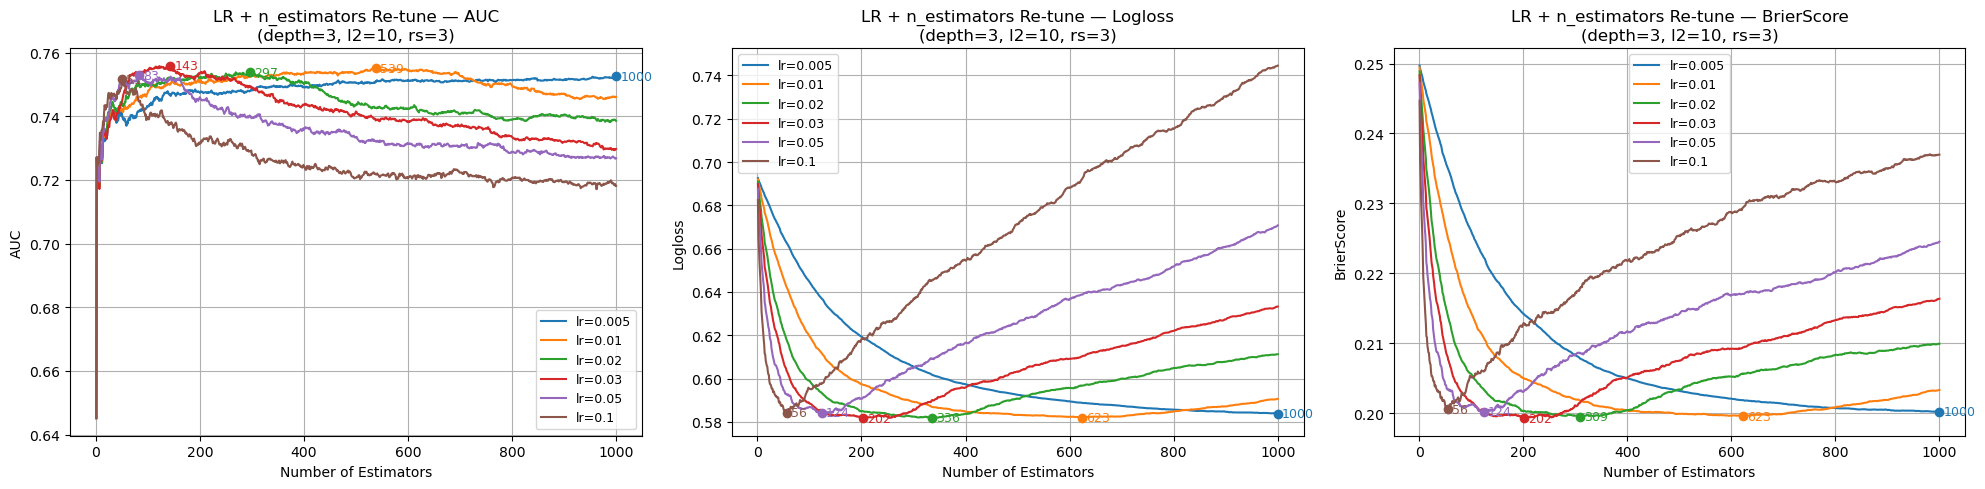

In [42]:
# Re-tuning n_estimators and learning_rate for the new config (depth=3, l2=10, rs=3).
# Shallower trees with stronger regularization may converge differently —
# the optimal number of trees and learning rate found earlier may no longer hold.
# We use the same CV curve approach as step 1 for direct comparison.

learning_rates = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
metrics = ['AUC', 'Logloss', 'BrierScore']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_curves_new = {m: {} for m in metrics}

for lr in learning_rates:
    fold_curves = {m: [] for m in metrics}
    for train_idx, val_idx in skf.split(X_train_top6, y_train):
        X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        for metric in metrics:
            cb = CatBoostClassifier(
                n_estimators=1000,
                learning_rate=lr,
                depth=3,
                l2_leaf_reg=10,
                random_strength=3,
                random_state=42,
                verbose=0,
                eval_metric=metric,
            )
            cb.fit(X_tr_cv, y_tr_cv, eval_set=(X_val_cv, y_val_cv))
            fold_curves[metric].append(cb.get_evals_result()['validation'][metric])

    for metric in metrics:
        lr_curves_new[metric][lr] = np.mean(fold_curves[metric], axis=0)

# One subplot per metric, all learning rates on the same plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, metric in zip(axes, metrics):
    higher_is_better = metric == 'AUC'

    for lr, color in zip(learning_rates, colors):
        curve = lr_curves_new[metric][lr]
        n_iters = np.arange(1, len(curve) + 1)
        best_n = int(np.argmax(curve) if higher_is_better else np.argmin(curve)) + 1
        best_val = curve[best_n - 1]

        ax.plot(n_iters, curve, color=color, linewidth=1.5, label=f'lr={lr}')
        ax.scatter([best_n], [best_val], color=color, zorder=5)
        ax.text(best_n + 8, best_val, f'{best_n}', va='center', fontsize=9, color=color)
        print(f"{metric:12s}  lr={lr:.3f}  — optimal n_estimators: {best_n:5d}  |  {metric}: {best_val:.4f}")

    ax.set_xlabel('Number of Estimators')
    ax.set_ylabel(metric)
    ax.set_title(f'LR + n_estimators Re-tune — {metric}\n(depth=3, l2=10, rs=3)')
    ax.legend(fontsize=9)
    ax.grid(True)
    print()

plt.tight_layout()
plt.show()


In [43]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []

for train_idx, val_idx in skf.split(X_train_top6, y_train):
    X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
    y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

    cb = CatBoostClassifier(
        n_estimators=202,
        learning_rate=0.03,
        depth=3,
        l2_leaf_reg=10,
        random_strength=3,
        random_state=42,
        verbose=0,
    )
    cb.fit(X_tr_cv, y_tr_cv)
    proba       = cb.predict_proba(X_val_cv)[:, 1]
    proba_train = cb.predict_proba(X_tr_cv)[:, 1]

    fold_val_auc.append(roc_auc_score(y_val_cv, proba))
    fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
    fold_logloss.append(log_loss(y_val_cv, proba))
    fold_brier.append(brier_score_loss(y_val_cv, proba))

print(f"CV AUC:      {np.mean(fold_val_auc):.4f}")
print(f"Train AUC:   {np.mean(fold_train_auc):.4f}")
print(f"Overfit Gap: {np.mean(fold_train_auc) - np.mean(fold_val_auc):.4f}")
print(f"Logloss:     {np.mean(fold_logloss):.4f}")
print(f"BrierScore:  {np.mean(fold_brier):.4f}")


CV AUC:      0.7539
Train AUC:   0.8239
Overfit Gap: 0.0700
Logloss:     0.5817
BrierScore:  0.1993


n=143  l2=10  — AUC: 0.7529  Gap: 0.0331  Logloss: 0.5920  Brier: 0.2029
n=143  l2=20  — AUC: 0.7503  Gap: 0.0285  Logloss: 0.5979  Brier: 0.2053
n=143  l2=30  — AUC: 0.7465  Gap: 0.0286  Logloss: 0.6025  Brier: 0.2072
n=143  l2=50  — AUC: 0.7452  Gap: 0.0250  Logloss: 0.6105  Brier: 0.2106
n=170  l2=10  — AUC: 0.7532  Gap: 0.0364  Logloss: 0.5890  Brier: 0.2018
n=170  l2=20  — AUC: 0.7508  Gap: 0.0312  Logloss: 0.5939  Brier: 0.2037
n=170  l2=30  — AUC: 0.7484  Gap: 0.0300  Logloss: 0.5981  Brier: 0.2054
n=170  l2=50  — AUC: 0.7451  Gap: 0.0274  Logloss: 0.6054  Brier: 0.2084
n=202  l2=10  — AUC: 0.7539  Gap: 0.0700  Logloss: 0.5817  Brier: 0.1993
n=202  l2=20  — AUC: 0.7532  Gap: 0.0637  Logloss: 0.5814  Brier: 0.1991
n=202  l2=30  — AUC: 0.7540  Gap: 0.0586  Logloss: 0.5821  Brier: 0.1994
n=202  l2=50  — AUC: 0.7546  Gap: 0.0529  Logloss: 0.5816  Brier: 0.1991
n=250  l2=10  — AUC: 0.7519  Gap: 0.0848  Logloss: 0.5823  Brier: 0.1995
n=250  l2=20  — AUC: 0.7517  Gap: 0.0774  Logloss: 

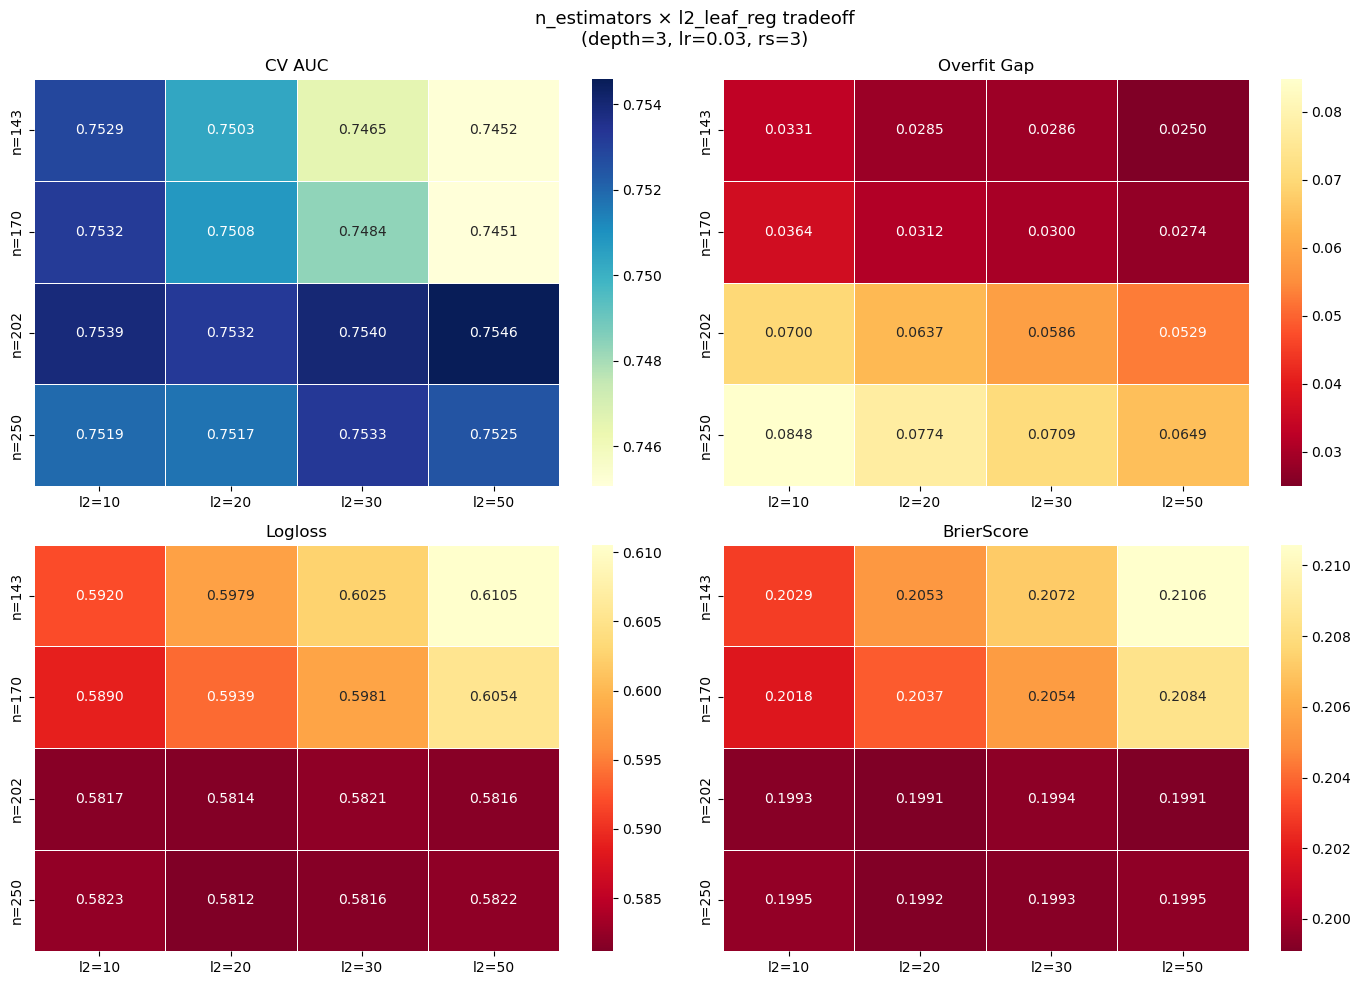

In [44]:
# Targeted grid to find the best n_estimators × l2_leaf_reg tradeoff
# between CV AUC and overfit gap, keeping depth=3, rs=3, lr=0.03 fixed.

n_est_values = [143, 170, 202, 250]
l2_values_new = [10, 20, 30, 50]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tradeoff_results = []

for n_est, l2 in product(n_est_values, l2_values_new):
    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []

    for train_idx, val_idx in skf.split(X_train_top6, y_train):
        X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(
            n_estimators=n_est,
            learning_rate=0.03,
            depth=3,
            l2_leaf_reg=l2,
            random_strength=3,
            random_state=42,
            verbose=0,
        )
        cb.fit(X_tr_cv, y_tr_cv)
        proba       = cb.predict_proba(X_val_cv)[:, 1]
        proba_train = cb.predict_proba(X_tr_cv)[:, 1]

        fold_val_auc.append(roc_auc_score(y_val_cv, proba))
        fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
        fold_logloss.append(log_loss(y_val_cv, proba))
        fold_brier.append(brier_score_loss(y_val_cv, proba))

    tradeoff_results.append({
        'n_estimators': n_est,
        'l2_leaf_reg':  l2,
        'CV AUC':       np.mean(fold_val_auc),
        'Overfit Gap':  np.mean(fold_train_auc) - np.mean(fold_val_auc),
        'Logloss':      np.mean(fold_logloss),
        'BrierScore':   np.mean(fold_brier),
    })
    print(f"n={n_est:3d}  l2={l2:2d}  — AUC: {np.mean(fold_val_auc):.4f}  Gap: {np.mean(fold_train_auc)-np.mean(fold_val_auc):.4f}  Logloss: {np.mean(fold_logloss):.4f}  Brier: {np.mean(fold_brier):.4f}")

df_tradeoff = pd.DataFrame(tradeoff_results)

# Heatmaps — one per metric
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cmap_config = {'CV AUC': 'YlGnBu', 'Overfit Gap': 'YlOrRd_r', 'Logloss': 'YlOrRd_r', 'BrierScore': 'YlOrRd_r'}

for ax, metric in zip(axes.flat, ['CV AUC', 'Overfit Gap', 'Logloss', 'BrierScore']):
    matrix = pd.DataFrame(
        [[df_tradeoff[(df_tradeoff['n_estimators']==n) & (df_tradeoff['l2_leaf_reg']==l2)][metric].values[0]
          for l2 in l2_values_new] for n in n_est_values],
        index=[f'n={n}' for n in n_est_values],
        columns=[f'l2={l2}' for l2 in l2_values_new]
    )
    sns.heatmap(matrix, annot=True, fmt='.4f', cmap=cmap_config[metric], ax=ax, linewidths=0.5)
    ax.set_title(f'{metric}')

plt.suptitle('n_estimators × l2_leaf_reg tradeoff\n(depth=3, lr=0.03, rs=3)', fontsize=13)
plt.tight_layout()
plt.show()


min_leaf= 1  border= 32  — AUC: 0.7509  Gap: 0.0369  Logloss: 0.5897  Brier: 0.2020
min_leaf= 1  border= 64  — AUC: 0.7522  Gap: 0.0340  Logloss: 0.5887  Brier: 0.2017
min_leaf= 1  border=128  — AUC: 0.7540  Gap: 0.0351  Logloss: 0.5884  Brier: 0.2015
min_leaf= 1  border=254  — AUC: 0.7532  Gap: 0.0364  Logloss: 0.5890  Brier: 0.2018
min_leaf= 5  border= 32  — AUC: 0.7509  Gap: 0.0369  Logloss: 0.5897  Brier: 0.2020
min_leaf= 5  border= 64  — AUC: 0.7522  Gap: 0.0340  Logloss: 0.5887  Brier: 0.2017
min_leaf= 5  border=128  — AUC: 0.7540  Gap: 0.0351  Logloss: 0.5884  Brier: 0.2015
min_leaf= 5  border=254  — AUC: 0.7532  Gap: 0.0364  Logloss: 0.5890  Brier: 0.2018
min_leaf=10  border= 32  — AUC: 0.7509  Gap: 0.0369  Logloss: 0.5897  Brier: 0.2020
min_leaf=10  border= 64  — AUC: 0.7522  Gap: 0.0340  Logloss: 0.5887  Brier: 0.2017
min_leaf=10  border=128  — AUC: 0.7540  Gap: 0.0351  Logloss: 0.5884  Brier: 0.2015
min_leaf=10  border=254  — AUC: 0.7532  Gap: 0.0364  Logloss: 0.5890  Brier:

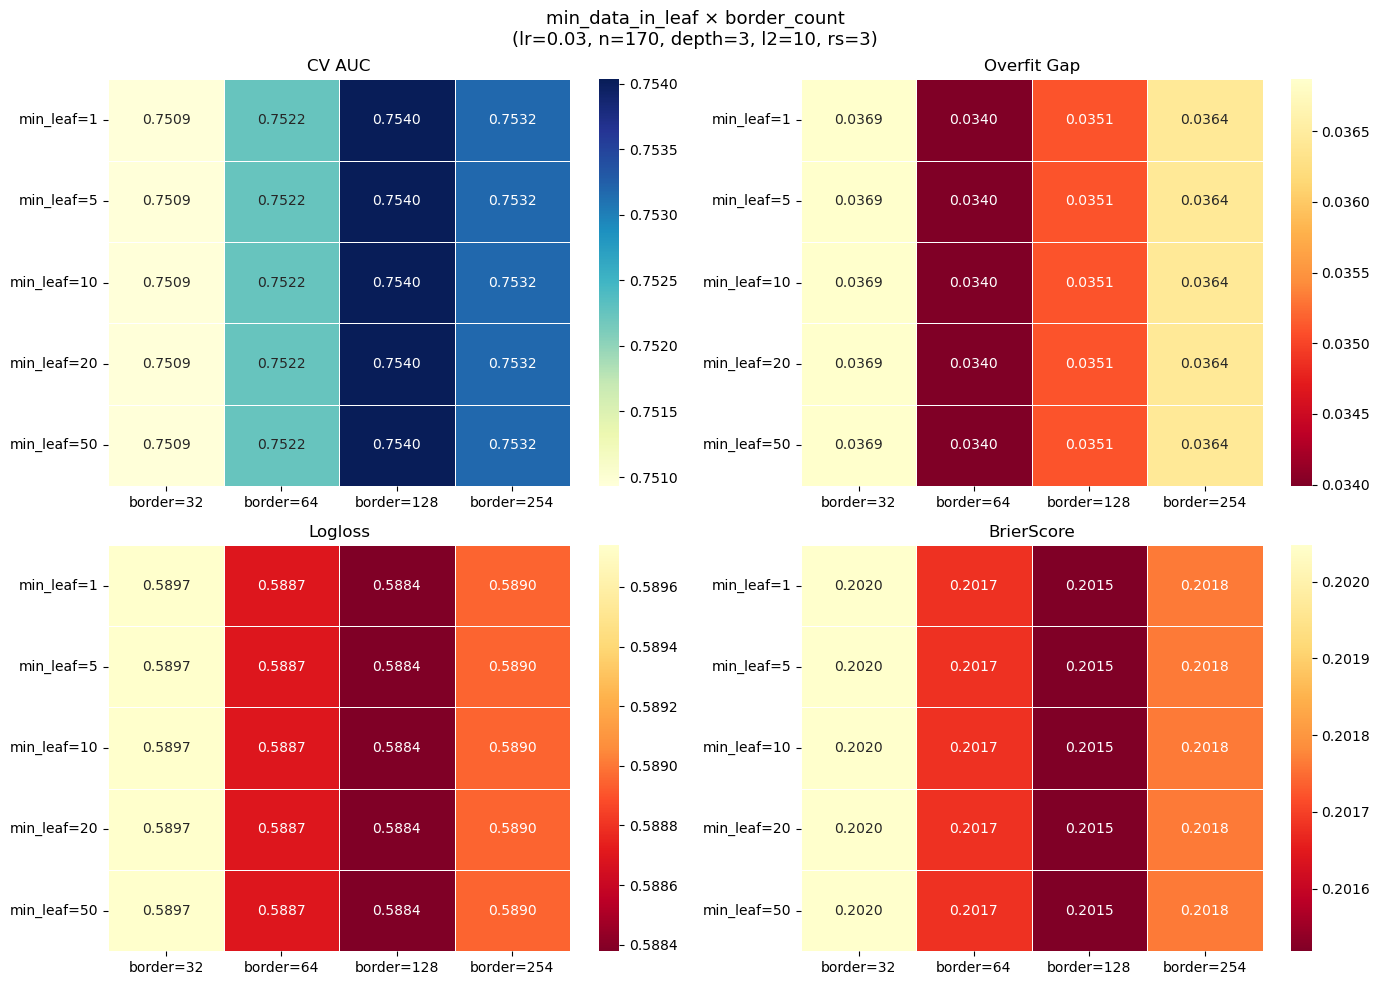

In [45]:
# Tuning min_data_in_leaf and border_count for the 6-feature model.
# min_data_in_leaf: minimum samples required in a leaf — with depth=3 and only 6 features,
# this constraint is more likely to activate than before, potentially preventing overfit splits.
# border_count: number of candidate split points per feature (default=254). Reducing it
# simplifies the model and can reduce overfitting — especially useful with few features.
# We fix all previous best params: lr=0.03, n=170, depth=3, l2=10, rs=3.

min_leaf_values  = [1, 5, 10, 20, 50]
border_values    = [32, 64, 128, 254]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bc_results = {m: {} for m in ['CV AUC', 'Overfit Gap', 'Logloss', 'BrierScore']}

for min_leaf, border in product(min_leaf_values, border_values):
    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []

    for train_idx, val_idx in skf.split(X_train_top6, y_train):
        X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(
            n_estimators=170,
            learning_rate=0.03,
            depth=3,
            l2_leaf_reg=10,
            random_strength=3,
            min_data_in_leaf=min_leaf,
            border_count=border,
            random_state=42,
            verbose=0,
        )
        cb.fit(X_tr_cv, y_tr_cv)
        proba       = cb.predict_proba(X_val_cv)[:, 1]
        proba_train = cb.predict_proba(X_tr_cv)[:, 1]

        fold_val_auc.append(roc_auc_score(y_val_cv, proba))
        fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
        fold_logloss.append(log_loss(y_val_cv, proba))
        fold_brier.append(brier_score_loss(y_val_cv, proba))

    bc_results['CV AUC'][(min_leaf, border)]      = np.mean(fold_val_auc)
    bc_results['Overfit Gap'][(min_leaf, border)] = np.mean(fold_train_auc) - np.mean(fold_val_auc)
    bc_results['Logloss'][(min_leaf, border)]     = np.mean(fold_logloss)
    bc_results['BrierScore'][(min_leaf, border)]  = np.mean(fold_brier)
    print(f"min_leaf={min_leaf:2d}  border={border:3d}  — AUC: {np.mean(fold_val_auc):.4f}  Gap: {np.mean(fold_train_auc)-np.mean(fold_val_auc):.4f}  Logloss: {np.mean(fold_logloss):.4f}  Brier: {np.mean(fold_brier):.4f}")

# Heatmaps — one per metric
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cmap_config = {'CV AUC': 'YlGnBu', 'Overfit Gap': 'YlOrRd_r', 'Logloss': 'YlOrRd_r', 'BrierScore': 'YlOrRd_r'}

for ax, metric in zip(axes.flat, ['CV AUC', 'Overfit Gap', 'Logloss', 'BrierScore']):
    matrix = pd.DataFrame(
        [[bc_results[metric][(min_leaf, border)] for border in border_values] for min_leaf in min_leaf_values],
        index=[f'min_leaf={m}' for m in min_leaf_values],
        columns=[f'border={b}' for b in border_values]
    )
    sns.heatmap(matrix, annot=True, fmt='.4f', cmap=cmap_config[metric], ax=ax, linewidths=0.5)
    ax.set_title(f'{metric}')

    best = max(bc_results[metric], key=bc_results[metric].get) if metric == 'CV AUC' \
           else min(bc_results[metric], key=bc_results[metric].get)
    print(f"Best {metric}: min_leaf={best[0]}, border={best[1]}  — {bc_results[metric][best]:.4f}")

plt.suptitle('min_data_in_leaf × border_count\n(lr=0.03, n=170, depth=3, l2=10, rs=3)', fontsize=13)
plt.tight_layout()
plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

0.04s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.



Best CV AUC: 0.7586
Best params:
  n_estimators: 212
  learning_rate: 0.041731646421531196
  depth: 5
  l2_leaf_reg: 8.225564056765132
  random_strength: 5.718929807099261
  border_count: 64

CV AUC:      0.7586
Train AUC:   0.8943
Overfit Gap: 0.1357
Logloss:     0.5833
BrierScore:  0.1994


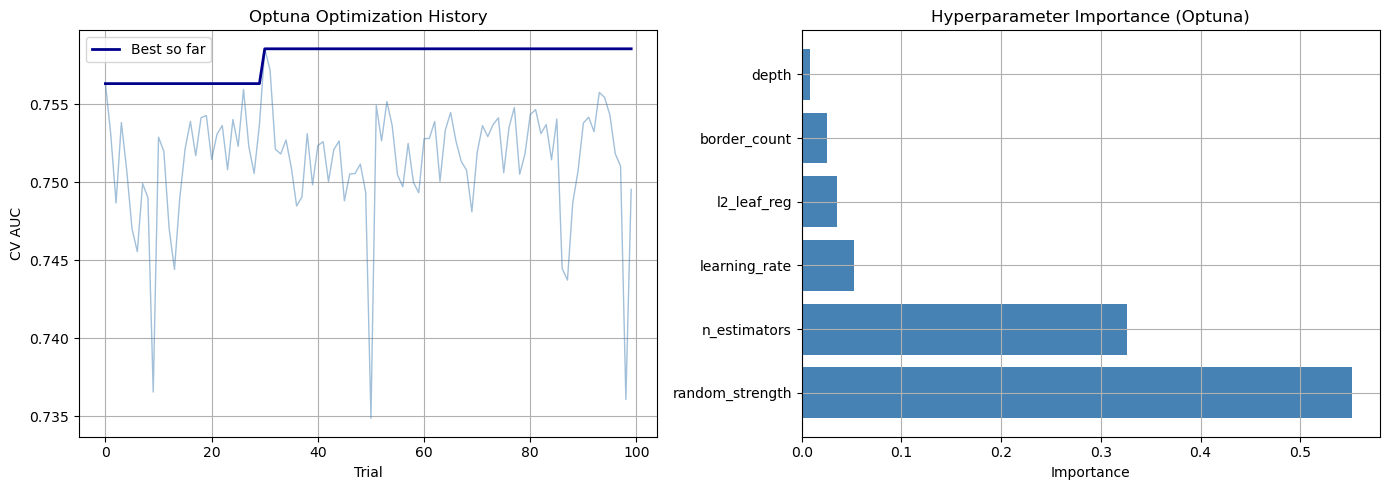

In [47]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Bayesian hyperparameter search with Optuna.
# Instead of manually defining grids, Optuna learns from previous trials and focuses
# the search on promising regions of the parameter space — more efficient than grid search.
# Search space is informed by our manual tuning: we know the rough optimal ranges,
# so we narrow the bounds to avoid wasting trials on clearly bad configs.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 300),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'depth':           trial.suggest_int('depth', 3, 5),
        'l2_leaf_reg':     trial.suggest_float('l2_leaf_reg', 5, 50, log=True),
        'random_strength': trial.suggest_float('random_strength', 1, 10, log=True),
        'border_count':    trial.suggest_categorical('border_count', [64, 128, 254]),
        'random_state':    42,
        'verbose':         0,
    }

    fold_val_auc = []
    for train_idx, val_idx in skf.split(X_train_top6, y_train):
        X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(**params)
        cb.fit(X_tr_cv, y_tr_cv)
        proba = cb.predict_proba(X_val_cv)[:, 1]
        fold_val_auc.append(roc_auc_score(y_val_cv, proba))

    return np.mean(fold_val_auc)

# Run optimization — 100 trials, maximizing CV AUC
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Best result
print(f"\nBest CV AUC: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Compute full metrics for the best config
fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []
for train_idx, val_idx in skf.split(X_train_top6, y_train):
    X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
    y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

    cb = CatBoostClassifier(**study.best_params, random_state=42, verbose=0)
    cb.fit(X_tr_cv, y_tr_cv)
    proba       = cb.predict_proba(X_val_cv)[:, 1]
    proba_train = cb.predict_proba(X_tr_cv)[:, 1]

    fold_val_auc.append(roc_auc_score(y_val_cv, proba))
    fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
    fold_logloss.append(log_loss(y_val_cv, proba))
    fold_brier.append(brier_score_loss(y_val_cv, proba))

print(f"\nCV AUC:      {np.mean(fold_val_auc):.4f}")
print(f"Train AUC:   {np.mean(fold_train_auc):.4f}")
print(f"Overfit Gap: {np.mean(fold_train_auc) - np.mean(fold_val_auc):.4f}")
print(f"Logloss:     {np.mean(fold_logloss):.4f}")
print(f"BrierScore:  {np.mean(fold_brier):.4f}")

# Visualize optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial AUC over time — shows convergence
axes[0].plot([t.value for t in study.trials], color='steelblue', alpha=0.5, linewidth=1)
axes[0].plot(np.maximum.accumulate([t.value for t in study.trials]), color='darkblue', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV AUC')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()
axes[0].grid(True)

# Parameter importance
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()), color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance (Optuna)')
axes[1].grid(True)

plt.tight_layout()
plt.show()



--- Running Optuna with λ=0.3 ---


  0%|          | 0/100 [00:00<?, ?it/s]

CV AUC:      0.7553
Train AUC:   0.7831
Overfit Gap: 0.0278
Logloss:     0.5916
BrierScore:  0.2026
Best params: {'n_estimators': 131, 'learning_rate': 0.04949344852236078, 'depth': 3, 'l2_leaf_reg': 49.51717795734754, 'random_strength': 1.8821579676278295, 'border_count': 128}

--- Running Optuna with λ=0.5 ---


  0%|          | 0/100 [00:00<?, ?it/s]

CV AUC:      0.7541
Train AUC:   0.7782
Overfit Gap: 0.0242
Logloss:     0.5888
BrierScore:  0.2016
Best params: {'n_estimators': 190, 'learning_rate': 0.046338429885023596, 'depth': 3, 'l2_leaf_reg': 36.54613973818707, 'random_strength': 9.133460098205582, 'border_count': 128}

--- Running Optuna with λ=0.7 ---


  0%|          | 0/100 [00:00<?, ?it/s]

CV AUC:      0.7483
Train AUC:   0.7688
Overfit Gap: 0.0206
Logloss:     0.6217
BrierScore:  0.2154
Best params: {'n_estimators': 129, 'learning_rate': 0.019272460500365005, 'depth': 3, 'l2_leaf_reg': 44.58947301753764, 'random_strength': 2.365600392604221, 'border_count': 128}

--- Summary across λ values ---
       CV AUC  Overfit Gap  Logloss  BrierScore
λ=0.3  0.7553       0.0278   0.5916      0.2026
λ=0.5  0.7541       0.0242   0.5888      0.2016
λ=0.7  0.7483       0.0206   0.6217      0.2154


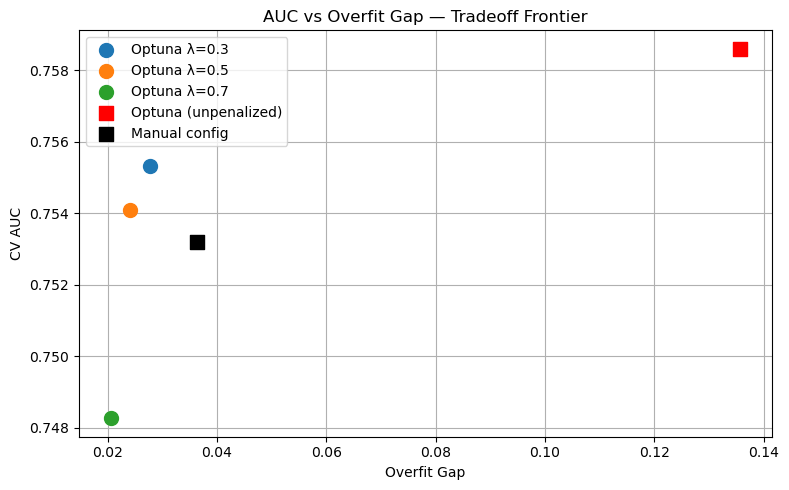

In [49]:
# Re-running Optuna with a penalized objective: AUC - λ * gap
# λ controls how much we penalize overfitting relative to AUC gain.
# λ=0.5 means: willing to give up 0.01 AUC to reduce gap by 0.02.
# We try three λ values to see the full tradeoff frontier.

lambdas = [0.3, 0.5, 0.7]
penalized_results = {}

for lam in lambdas:
    print(f"\n--- Running Optuna with λ={lam} ---")

    def objective_penalized(trial):
        params = {
            'n_estimators':    trial.suggest_int('n_estimators', 100, 300),
            'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
            'depth':           trial.suggest_int('depth', 3, 5),
            'l2_leaf_reg':     trial.suggest_float('l2_leaf_reg', 5, 50, log=True),
            'random_strength': trial.suggest_float('random_strength', 1, 10, log=True),
            'border_count':    trial.suggest_categorical('border_count', [64, 128, 254]),
            'random_state':    42,
            'verbose':         0,
        }

        fold_train_auc, fold_val_auc = [], []
        for train_idx, val_idx in skf.split(X_train_top6, y_train):
            X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
            y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

            cb = CatBoostClassifier(**params)
            cb.fit(X_tr_cv, y_tr_cv)
            fold_val_auc.append(roc_auc_score(y_val_cv, cb.predict_proba(X_val_cv)[:, 1]))
            fold_train_auc.append(roc_auc_score(y_tr_cv, cb.predict_proba(X_tr_cv)[:, 1]))

        val_auc = np.mean(fold_val_auc)
        gap     = np.mean(fold_train_auc) - val_auc
        return val_auc - lam * gap

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective_penalized, n_trials=100, show_progress_bar=True)

    # Recompute full metrics for best config
    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []
    for train_idx, val_idx in skf.split(X_train_top6, y_train):
        X_tr_cv, X_val_cv = X_train_top6.iloc[train_idx], X_train_top6.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(**study.best_params, random_state=42, verbose=0)
        cb.fit(X_tr_cv, y_tr_cv)
        proba       = cb.predict_proba(X_val_cv)[:, 1]
        proba_train = cb.predict_proba(X_tr_cv)[:, 1]

        fold_val_auc.append(roc_auc_score(y_val_cv, proba))
        fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
        fold_logloss.append(log_loss(y_val_cv, proba))
        fold_brier.append(brier_score_loss(y_val_cv, proba))

    penalized_results[lam] = {
        'CV AUC':      np.mean(fold_val_auc),
        'Train AUC':   np.mean(fold_train_auc),
        'Overfit Gap': np.mean(fold_train_auc) - np.mean(fold_val_auc),
        'Logloss':     np.mean(fold_logloss),
        'BrierScore':  np.mean(fold_brier),
        'params':      study.best_params,
        'study':       study,
    }
    print(f"CV AUC:      {penalized_results[lam]['CV AUC']:.4f}")
    print(f"Train AUC:   {penalized_results[lam]['Train AUC']:.4f}")
    print(f"Overfit Gap: {penalized_results[lam]['Overfit Gap']:.4f}")
    print(f"Logloss:     {penalized_results[lam]['Logloss']:.4f}")
    print(f"BrierScore:  {penalized_results[lam]['BrierScore']:.4f}")
    print(f"Best params: {study.best_params}")

# Summary table
print("\n--- Summary across λ values ---")
df_penalized = pd.DataFrame({
    f'λ={lam}': {
        'CV AUC':      penalized_results[lam]['CV AUC'],
        'Overfit Gap': penalized_results[lam]['Overfit Gap'],
        'Logloss':     penalized_results[lam]['Logloss'],
        'BrierScore':  penalized_results[lam]['BrierScore'],
    } for lam in lambdas
}).T.round(4)
print(df_penalized)

# Plot AUC vs Gap tradeoff across λ values + manual config + unpenalized Optuna
fig, ax = plt.subplots(figsize=(8, 5))
for lam in lambdas:
    ax.scatter(penalized_results[lam]['Overfit Gap'], penalized_results[lam]['CV AUC'],
               s=100, zorder=5, label=f'Optuna λ={lam}')
ax.scatter(0.1357, 0.7586, s=100, marker='s', color='red',    zorder=5, label='Optuna (unpenalized)')
ax.scatter(0.0364, 0.7532, s=100, marker='s', color='black',  zorder=5, label='Manual config')
ax.set_xlabel('Overfit Gap')
ax.set_ylabel('CV AUC')
ax.set_title('AUC vs Overfit Gap — Tradeoff Frontier')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


Baseline (all 6)                               AUC: 0.7553  Gap: 0.0278
----------------------------------------------------------------------
Drop [#_of_charting_songs_through_first_top_20]  AUC: 0.7039 (-0.0514)  Gap: 0.0345 (+0.0068)
Drop [betweenness_centrality_top20_rolling5   ]  AUC: 0.7506 (-0.0047)  Gap: 0.0301 (+0.0023)
Drop [harmonic_closeness_centrality_top20_roll]  AUC: 0.7512 (-0.0041)  Gap: 0.0281 (+0.0003)
Drop [#_of_genres_artist                      ]  AUC: 0.7401 (-0.0152)  Gap: 0.0279 (+0.0002)
Drop [eigenvector_centrality_top20_rolling5   ]  AUC: 0.7479 (-0.0074)  Gap: 0.0311 (+0.0033)
Drop [top_20_hit_song_#_wks_on_chart_any_posit]  AUC: 0.7497 (-0.0056)  Gap: 0.0291 (+0.0013)


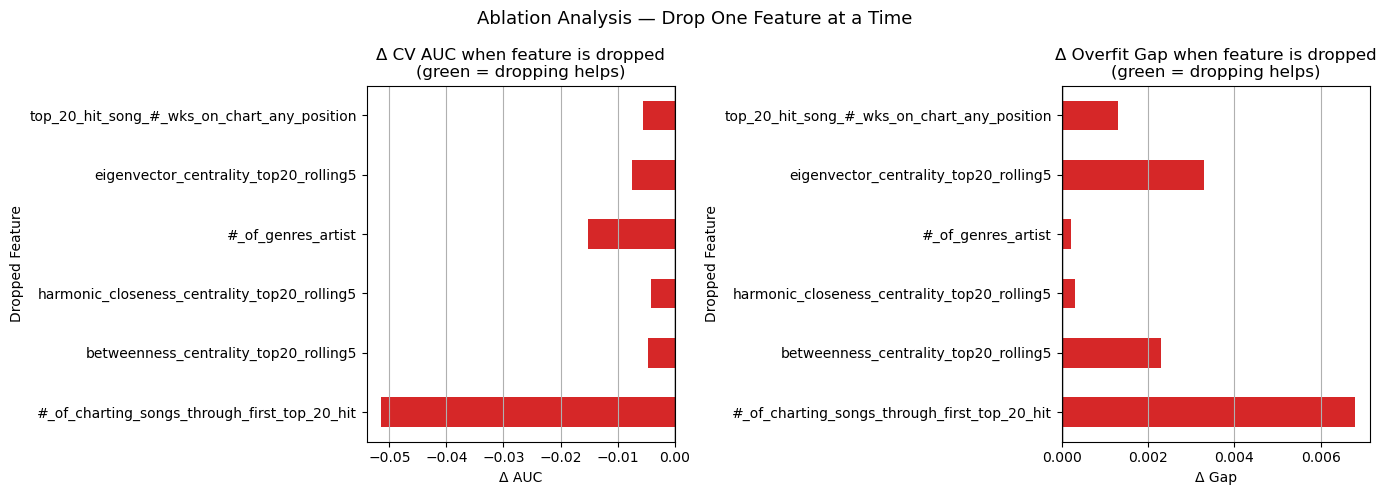

In [50]:
# Ablation analysis: systematically drop each feature one at a time and measure the impact
# on CV AUC and overfit gap. If dropping a feature improves both metrics, it's adding noise
# rather than signal. We use the final Optuna λ=0.3 config as the baseline.

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_params = {
    'n_estimators':    131,
    'learning_rate':   0.04949344852236078,
    'depth':           3,
    'l2_leaf_reg':     49.51717795734754,
    'random_strength': 1.8821579676278295,
    'border_count':    128,
    'random_state':    42,
    'verbose':         0,
}

def evaluate_features(X, y, params, skf):
    fold_train_auc, fold_val_auc = [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        cb = CatBoostClassifier(**params)
        cb.fit(X_tr, y_tr)
        fold_val_auc.append(roc_auc_score(y_val, cb.predict_proba(X_val)[:, 1]))
        fold_train_auc.append(roc_auc_score(y_tr, cb.predict_proba(X_tr)[:, 1]))
    return np.mean(fold_val_auc), np.mean(fold_train_auc) - np.mean(fold_val_auc)

# Baseline — all 6 features
baseline_auc, baseline_gap = evaluate_features(X_train_top6, y_train, best_params, skf)
print(f"{'Baseline (all 6)':45s}  AUC: {baseline_auc:.4f}  Gap: {baseline_gap:.4f}")
print("-" * 70)

ablation_results = []
for feature in top6_features:
    features_minus_one = [f for f in top6_features if f != feature]
    X_ablated = X_train_clean[features_minus_one]
    auc, gap = evaluate_features(X_ablated, y_train, best_params, skf)
    delta_auc = auc - baseline_auc
    delta_gap = gap - baseline_gap
    ablation_results.append({
        'Dropped Feature': feature,
        'CV AUC':          auc,
        'Δ AUC':           delta_auc,
        'Overfit Gap':     gap,
        'Δ Gap':           delta_gap,
    })
    print(f"Drop [{feature[:40]:40s}]  AUC: {auc:.4f} ({delta_auc:+.4f})  Gap: {gap:.4f} ({delta_gap:+.4f})")

df_ablation = pd.DataFrame(ablation_results).set_index('Dropped Feature').round(4)

# Visualize — two bar charts side by side: ΔAUC and ΔGap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color: green if dropping helps (positive ΔAUC or negative ΔGap), red if hurts
auc_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in df_ablation['Δ AUC']]
gap_colors = ['#2ca02c' if v <= 0 else '#d62728' for v in df_ablation['Δ Gap']]

df_ablation['Δ AUC'].plot(kind='barh', ax=axes[0], color=auc_colors)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Δ CV AUC when feature is dropped\n(green = dropping helps)')
axes[0].set_xlabel('Δ AUC')
axes[0].grid(True, axis='x')

df_ablation['Δ Gap'].plot(kind='barh', ax=axes[1], color=gap_colors)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Δ Overfit Gap when feature is dropped\n(green = dropping helps)')
axes[1].set_xlabel('Δ Gap')
axes[1].grid(True, axis='x')

plt.suptitle('Ablation Analysis — Drop One Feature at a Time', fontsize=13)
plt.tight_layout()
plt.show()


In [51]:
# Replicate the XGBoost notebook's feature set on CatBoost.
# Their final 9 features: 2 charting metrics, 1 network centrality (betweenness only),
# 4 individual genres (Pop, Rock, Hip Hop/Rap, R&B/Soul/Funk),
# 1 consolidated genre (artist_genre_other = all remaining genres combined),
# and #_of_genres_artist.

# Step 1: create artist_genre_other by combining all low-signal genres
high_signal_genres = [
    'artist_genre_Pop',
    'artist_genre_Rock',
    'artist_genre_Hip Hop/Rap',
    'artist_genre_R&B/Soul/Funk',
]
all_genre_cols = [c for c in X_train_clean.columns if c.startswith('artist_genre_')]
low_signal_genres = [c for c in all_genre_cols if c not in high_signal_genres]

X_train_xgb = X_train_clean.copy()
X_train_xgb['artist_genre_other'] = (X_train_xgb[low_signal_genres].sum(axis=1) > 0).astype(int)

# Step 2: assemble their exact 9-feature set
xgb_features = [
    '#_of_charting_songs_through_first_top_20_hit',
    'top_20_hit_song_#_wks_on_chart_any_position',
    '#_of_genres_artist',
    'betweenness_centrality_top20_rolling5',
    'artist_genre_Pop',
    'artist_genre_Rock',
    'artist_genre_Hip Hop/Rap',
    'artist_genre_R&B/Soul/Funk',
    'artist_genre_other',
]
X_train_xgb9 = X_train_xgb[xgb_features]
print(f"Feature set: {xgb_features}")
print(f"Shape: {X_train_xgb9.shape}")

# Step 3: quick baseline CV with current best params before Optuna
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []

for train_idx, val_idx in skf.split(X_train_xgb9, y_train):
    X_tr_cv, X_val_cv = X_train_xgb9.iloc[train_idx], X_train_xgb9.iloc[val_idx]
    y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

    cb = CatBoostClassifier(**best_params)
    cb.fit(X_tr_cv, y_tr_cv)
    proba       = cb.predict_proba(X_val_cv)[:, 1]
    proba_train = cb.predict_proba(X_tr_cv)[:, 1]

    fold_val_auc.append(roc_auc_score(y_val_cv, proba))
    fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
    fold_logloss.append(log_loss(y_val_cv, proba))
    fold_brier.append(brier_score_loss(y_val_cv, proba))

print(f"\nBaseline (9 features, current params):")
print(f"CV AUC:      {np.mean(fold_val_auc):.4f}")
print(f"Train AUC:   {np.mean(fold_train_auc):.4f}")
print(f"Overfit Gap: {np.mean(fold_train_auc) - np.mean(fold_val_auc):.4f}")
print(f"Logloss:     {np.mean(fold_logloss):.4f}")
print(f"BrierScore:  {np.mean(fold_brier):.4f}")


Feature set: ['#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', '#_of_genres_artist', 'betweenness_centrality_top20_rolling5', 'artist_genre_Pop', 'artist_genre_Rock', 'artist_genre_Hip Hop/Rap', 'artist_genre_R&B/Soul/Funk', 'artist_genre_other']
Shape: (607, 9)

Baseline (9 features, current params):
CV AUC:      0.7567
Train AUC:   0.7860
Overfit Gap: 0.0292
Logloss:     0.5887
BrierScore:  0.2016


Original features:     25
Consolidated features: 11

Feature list:
['#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Hip Hop/Rap', 'artist_genre_Pop', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Rock', '#_of_genres_artist', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'artist_genre_other']

Feature importance order:
                                     Feature  Importance
#_of_charting_songs_through_first_top_20_hit   43.343844
                          #_of_genres_artist   12.443606
       eigenvector_centrality_top20_rolling5    9.967010
       betweenness_centrality_top20_rolling5    9.721322
                            artist_genre_Pop    8.246756
harmonic_closeness_centrality_top20_rolling5    5.200968
 top_20_hit_song_#_wks_on_chart_any_position    3.578823
                    artist_genre_Hip Hop/Rap    2.674494
                        

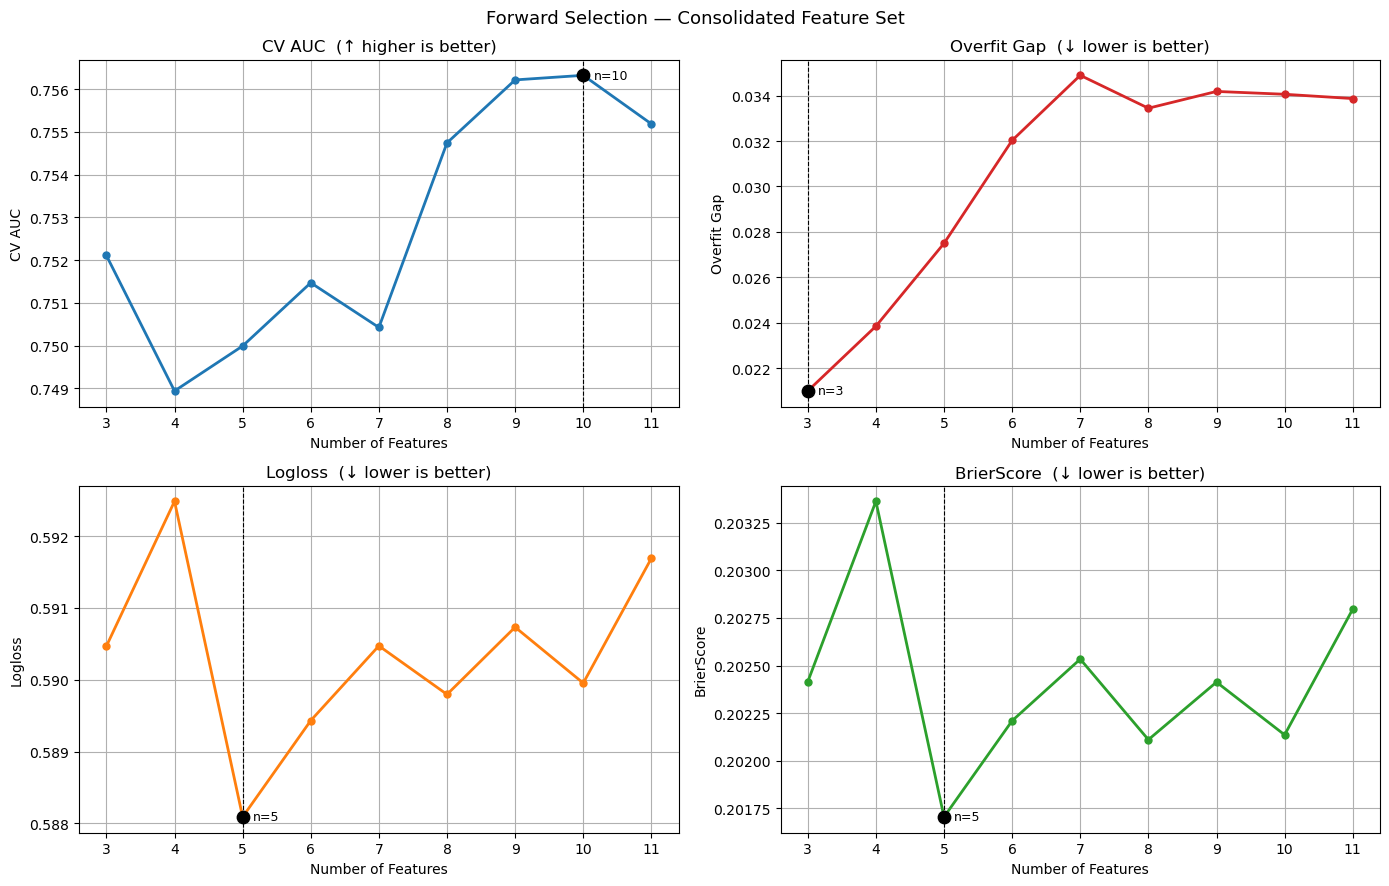

In [52]:
# Step 1: Create the consolidated feature set.
# We keep the 4 high-signal genres separate and combine the remaining 14 into artist_genre_other.
# This gives genres a fair chance as a signal without overfitting to rare patterns.

high_signal_genres = [
    'artist_genre_Pop',
    'artist_genre_Rock',
    'artist_genre_Hip Hop/Rap',
    'artist_genre_R&B/Soul/Funk',
]
all_genre_cols = [c for c in X_train_clean.columns if c.startswith('artist_genre_')]
low_signal_genres = [c for c in all_genre_cols if c not in high_signal_genres]

# Build new feature matrix: drop 14 low-signal genres, add artist_genre_other
X_train_consolidated = X_train_clean.drop(columns=low_signal_genres).copy()
X_train_consolidated['artist_genre_other'] = (X_train_clean[low_signal_genres].sum(axis=1) > 0).astype(int)

print(f"Original features:     {X_train_clean.shape[1]}")
print(f"Consolidated features: {X_train_consolidated.shape[1]}")
print(f"\nFeature list:\n{X_train_consolidated.columns.tolist()}")

# Step 2: Fit CatBoost on all consolidated features to get importance order for forward selection
cb_consolidated = CatBoostClassifier(
    n_estimators=131,
    learning_rate=0.04949344852236078,
    depth=3,
    l2_leaf_reg=49.51717795734754,
    random_strength=1.8821579676278295,
    border_count=128,
    random_state=42,
    verbose=0,
)
cb_consolidated.fit(X_train_consolidated, y_train)

feat_imp_consolidated = cb_consolidated.get_feature_importance(prettified=True)
feat_imp_consolidated.columns = ['Feature', 'Importance']
feat_imp_consolidated = feat_imp_consolidated.sort_values('Importance', ascending=False)
feature_order_consolidated = feat_imp_consolidated['Feature'].tolist()

print("\nFeature importance order:")
print(feat_imp_consolidated.to_string(index=False))

# Step 3: Forward selection — start from top 3, add one feature at a time
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
selection_results_consolidated = []

for n_feats in range(3, len(feature_order_consolidated) + 1):
    features_subset = feature_order_consolidated[:n_feats]
    X_subset = X_train_consolidated[features_subset]

    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []

    for train_idx, val_idx in skf.split(X_subset, y_train):
        X_tr_cv, X_val_cv = X_subset.iloc[train_idx], X_subset.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cb = CatBoostClassifier(
            n_estimators=131,
            learning_rate=0.04949344852236078,
            depth=3,
            l2_leaf_reg=49.51717795734754,
            random_strength=1.8821579676278295,
            border_count=128,
            random_state=42,
            verbose=0,
        )
        cb.fit(X_tr_cv, y_tr_cv)
        proba       = cb.predict_proba(X_val_cv)[:, 1]
        proba_train = cb.predict_proba(X_tr_cv)[:, 1]

        fold_val_auc.append(roc_auc_score(y_val_cv, proba))
        fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
        fold_logloss.append(log_loss(y_val_cv, proba))
        fold_brier.append(brier_score_loss(y_val_cv, proba))

    val_auc   = np.mean(fold_val_auc)
    train_auc = np.mean(fold_train_auc)
    selection_results_consolidated.append({
        'n_features':  n_feats,
        'last_added':  feature_order_consolidated[n_feats - 1],
        'CV AUC':      val_auc,
        'Train AUC':   train_auc,
        'Overfit Gap': train_auc - val_auc,
        'Logloss':     np.mean(fold_logloss),
        'BrierScore':  np.mean(fold_brier),
    })
    print(f"n={n_feats:2d}  +[{feature_order_consolidated[n_feats-1][:40]:40s}]  AUC: {val_auc:.4f}  Gap: {train_auc - val_auc:.4f}  Logloss: {np.mean(fold_logloss):.4f}  Brier: {np.mean(fold_brier):.4f}")

df_sel_consolidated = pd.DataFrame(selection_results_consolidated).set_index('n_features')

# 4 subplots — one per metric
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics_plot = [
    ('CV AUC',      '#1f77b4', 'higher'),
    ('Overfit Gap', '#d62728', 'lower'),
    ('Logloss',     '#ff7f0e', 'lower'),
    ('BrierScore',  '#2ca02c', 'lower'),
]

for ax, (metric, color, better) in zip(axes.flat, metrics_plot):
    ax.plot(df_sel_consolidated.index, df_sel_consolidated[metric], 'o-', color=color, linewidth=2, markersize=5)
    best_n = df_sel_consolidated[metric].idxmax() if better == 'higher' else df_sel_consolidated[metric].idxmin()
    best_val = df_sel_consolidated[metric][best_n]
    ax.scatter([best_n], [best_val], color='black', zorder=5, s=80)
    ax.axvline(best_n, color='black', linestyle='--', linewidth=0.8)
    ax.text(best_n + 0.15, best_val, f'n={best_n}', fontsize=9, va='center')
    ax.set_xlabel('Number of Features')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}  ({"↑ higher" if better == "higher" else "↓ lower"} is better)')
    ax.grid(True)

plt.suptitle('Forward Selection — Consolidated Feature Set', fontsize=13)
plt.tight_layout()
plt.show()


In [53]:
# Run penalized Optuna (λ=0.3) on three candidate feature subsets from forward selection.
# n=3: lowest gap, n=5: best calibration, n=10: best AUC.
# This lets Optuna resolve the tradeoff for each subset and we pick the best overall.

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

lam = 0.3
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidate_subsets = {
    'n=3':  feature_order_consolidated[:3],
    'n=5':  feature_order_consolidated[:5],
    'n=10': feature_order_consolidated[:10],
}

optuna_results = {}

for subset_name, features in candidate_subsets.items():
    print(f"\n--- Optuna λ=0.3 on {subset_name}: {features} ---")
    X_subset = X_train_consolidated[features]

    def objective(trial):
        params = {
            'n_estimators':    trial.suggest_int('n_estimators', 100, 300),
            'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
            'depth':           trial.suggest_int('depth', 3, 5),
            'l2_leaf_reg':     trial.suggest_float('l2_leaf_reg', 5, 50, log=True),
            'random_strength': trial.suggest_float('random_strength', 1, 10, log=True),
            'border_count':    trial.suggest_categorical('border_count', [64, 128, 254]),
            'random_state':    42,
            'verbose':         0,
        }
        fold_train_auc, fold_val_auc = [], []
        for train_idx, val_idx in skf.split(X_subset, y_train):
            X_tr_cv, X_val_cv = X_subset.iloc[train_idx], X_subset.iloc[val_idx]
            y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
            cb = CatBoostClassifier(**params)
            cb.fit(X_tr_cv, y_tr_cv)
            fold_val_auc.append(roc_auc_score(y_val_cv, cb.predict_proba(X_val_cv)[:, 1]))
            fold_train_auc.append(roc_auc_score(y_tr_cv, cb.predict_proba(X_tr_cv)[:, 1]))
        val_auc = np.mean(fold_val_auc)
        gap     = np.mean(fold_train_auc) - val_auc
        return val_auc - lam * gap

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    # Full metrics for best config
    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []
    for train_idx, val_idx in skf.split(X_subset, y_train):
        X_tr_cv, X_val_cv = X_subset.iloc[train_idx], X_subset.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
        cb = CatBoostClassifier(**study.best_params, random_state=42, verbose=0)
        cb.fit(X_tr_cv, y_tr_cv)
        proba       = cb.predict_proba(X_val_cv)[:, 1]
        proba_train = cb.predict_proba(X_tr_cv)[:, 1]
        fold_val_auc.append(roc_auc_score(y_val_cv, proba))
        fold_train_auc.append(roc_auc_score(y_tr_cv, proba_train))
        fold_logloss.append(log_loss(y_val_cv, proba))
        fold_brier.append(brier_score_loss(y_val_cv, proba))

    optuna_results[subset_name] = {
        'features':    features,
        'CV AUC':      np.mean(fold_val_auc),
        'Train AUC':   np.mean(fold_train_auc),
        'Overfit Gap': np.mean(fold_train_auc) - np.mean(fold_val_auc),
        'Logloss':     np.mean(fold_logloss),
        'BrierScore':  np.mean(fold_brier),
        'params':      study.best_params,
    }
    print(f"CV AUC:      {optuna_results[subset_name]['CV AUC']:.4f}")
    print(f"Train AUC:   {optuna_results[subset_name]['Train AUC']:.4f}")
    print(f"Overfit Gap: {optuna_results[subset_name]['Overfit Gap']:.4f}")
    print(f"Logloss:     {optuna_results[subset_name]['Logloss']:.4f}")
    print(f"BrierScore:  {optuna_results[subset_name]['BrierScore']:.4f}")
    print(f"Best params: {study.best_params}")

# Final comparison table including previous best
print("\n--- Full comparison ---")
print(f"{'Config':35s}  {'CV AUC':>8}  {'Gap':>8}  {'Logloss':>8}  {'Brier':>8}")
print(f"{'Previous best (6 feat Optuna λ=0.3)':35s}  {'0.7553':>8}  {'0.0278':>8}  {'0.5916':>8}  {'0.2026':>8}")
for name, res in optuna_results.items():
    print(f"{'Consolidated ' + name + ' Optuna λ=0.3':35s}  {res['CV AUC']:>8.4f}  {res['Overfit Gap']:>8.4f}  {res['Logloss']:>8.4f}  {res['BrierScore']:>8.4f}")



--- Optuna λ=0.3 on n=3: ['#_of_charting_songs_through_first_top_20_hit', '#_of_genres_artist', 'eigenvector_centrality_top20_rolling5'] ---


  0%|          | 0/100 [00:00<?, ?it/s]

CV AUC:      0.7553
Train AUC:   0.7674
Overfit Gap: 0.0120
Logloss:     0.6005
BrierScore:  0.2063
Best params: {'n_estimators': 144, 'learning_rate': 0.034619037207140636, 'depth': 3, 'l2_leaf_reg': 49.797965510452286, 'random_strength': 3.1923611548354427, 'border_count': 64}

--- Optuna λ=0.3 on n=5: ['#_of_charting_songs_through_first_top_20_hit', '#_of_genres_artist', 'eigenvector_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'artist_genre_Pop'] ---


  0%|          | 0/100 [00:00<?, ?it/s]

CV AUC:      0.7547
Train AUC:   0.7776
Overfit Gap: 0.0229
Logloss:     0.6029
BrierScore:  0.2073
Best params: {'n_estimators': 108, 'learning_rate': 0.029873947981874583, 'depth': 3, 'l2_leaf_reg': 47.235085642385464, 'random_strength': 1.0493850669230669, 'border_count': 64}

--- Optuna λ=0.3 on n=10: ['#_of_charting_songs_through_first_top_20_hit', '#_of_genres_artist', 'eigenvector_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'artist_genre_Pop', 'harmonic_closeness_centrality_top20_rolling5', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Hip Hop/Rap', 'artist_genre_other', 'artist_genre_R&B/Soul/Funk'] ---


  0%|          | 0/100 [00:00<?, ?it/s]

CV AUC:      0.7614
Train AUC:   0.7916
Overfit Gap: 0.0302
Logloss:     0.5814
BrierScore:  0.1986
Best params: {'n_estimators': 175, 'learning_rate': 0.04992200445984842, 'depth': 3, 'l2_leaf_reg': 38.21139991113427, 'random_strength': 5.375884342277069, 'border_count': 254}

--- Full comparison ---
Config                                 CV AUC       Gap   Logloss     Brier
Previous best (6 feat Optuna λ=0.3)    0.7553    0.0278    0.5916    0.2026
Consolidated n=3 Optuna λ=0.3          0.7553    0.0120    0.6005    0.2063
Consolidated n=5 Optuna λ=0.3          0.7547    0.0229    0.6029    0.2073
Consolidated n=10 Optuna λ=0.3         0.7614    0.0302    0.5814    0.1986


In [54]:
# Final test set evaluation — compare all CatBoost candidates against XGBoost baseline.
# We fit each model on the full training set and evaluate once on the held-out test set.
# Note: imputer and consolidated features must be prepared consistently with training.

from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

# Prepare test set — impute and create consolidated features
imputer_final = SimpleImputer(strategy='median')
imputer_final.fit(X_train)
X_test_clean = pd.DataFrame(
    imputer_final.transform(X_test),
    columns=X_train.columns,
    index=X_test.index
)

# Create consolidated test set
X_test_consolidated = X_test_clean.drop(columns=low_signal_genres).copy()
X_test_consolidated['artist_genre_other'] = (X_test_clean[low_signal_genres].sum(axis=1) > 0).astype(int)

# Define all candidates
candidates = {
    'CatBoost 6 feat (prev best)': {
        'X_train': X_train_top6,
        'X_test':  X_test_clean[top6_features],
        'params':  {
            'n_estimators': 131, 'learning_rate': 0.04949344852236078,
            'depth': 3, 'l2_leaf_reg': 49.51717795734754,
            'random_strength': 1.8821579676278295, 'border_count': 128,
            'random_state': 42, 'verbose': 0,
        }
    },
    'CatBoost consolidated n=3': {
        'X_train': X_train_consolidated[feature_order_consolidated[:3]],
        'X_test':  X_test_consolidated[feature_order_consolidated[:3]],
        'params':  {
            'n_estimators': 144, 'learning_rate': 0.034619037207140636,
            'depth': 3, 'l2_leaf_reg': 49.797965510452286,
            'random_strength': 3.1923611548354427, 'border_count': 64,
            'random_state': 42, 'verbose': 0,
        }
    },
    'CatBoost consolidated n=10': {
        'X_train': X_train_consolidated[feature_order_consolidated[:10]],
        'X_test':  X_test_consolidated[feature_order_consolidated[:10]],
        'params':  {
            'n_estimators': 175, 'learning_rate': 0.04992200445984842,
            'depth': 3, 'l2_leaf_reg': 38.21139991113427,
            'random_strength': 5.375884342277069, 'border_count': 254,
            'random_state': 42, 'verbose': 0,
        }
    },
}

test_results = []

for name, config in candidates.items():
    cb = CatBoostClassifier(**config['params'])
    cb.fit(config['X_train'], y_train)

    proba_test  = cb.predict_proba(config['X_test'])[:, 1]
    proba_train = cb.predict_proba(config['X_train'])[:, 1]

    test_results.append({
        'Model':        name,
        'Test AUC':     roc_auc_score(y_test, proba_test),
        'Train AUC':    roc_auc_score(y_train, proba_train),
        'Overfit Gap':  roc_auc_score(y_train, proba_train) - roc_auc_score(y_test, proba_test),
        'Logloss':      log_loss(y_test, proba_test),
        'BrierScore':   brier_score_loss(y_test, proba_test),
        'N Features':   config['X_train'].shape[1],
    })
    print(f"{name}: Test AUC={test_results[-1]['Test AUC']:.4f}  Gap={test_results[-1]['Overfit Gap']:.4f}  Logloss={test_results[-1]['Logloss']:.4f}  Brier={test_results[-1]['BrierScore']:.4f}")

# Add XGBoost reported results from ml_sandbox_16 for direct comparison
test_results.append({
    'Model':       'XGBoost (ml_sandbox_16)',
    'Test AUC':    0.7658,
    'Train AUC':   0.7815,
    'Overfit Gap': 0.0157,
    'Logloss':     0.5693,
    'BrierScore':  0.1936,
    'N Features':  22,
})

df_test = pd.DataFrame(test_results).set_index('Model').round(4)
print(f"\n--- Final Test Set Comparison ---")
print(df_test.to_string())


CatBoost 6 feat (prev best): Test AUC=0.7544  Gap=0.0249  Logloss=0.5870  Brier=0.2005
CatBoost consolidated n=3: Test AUC=0.7410  Gap=0.0240  Logloss=0.6014  Brier=0.2068
CatBoost consolidated n=10: Test AUC=0.7634  Gap=0.0254  Logloss=0.5758  Brier=0.1956

--- Final Test Set Comparison ---
                             Test AUC  Train AUC  Overfit Gap  Logloss  BrierScore  N Features
Model                                                                                         
CatBoost 6 feat (prev best)    0.7544     0.7793       0.0249   0.5870      0.2005           6
CatBoost consolidated n=3      0.7410     0.7651       0.0240   0.6014      0.2068           3
CatBoost consolidated n=10     0.7634     0.7888       0.0254   0.5758      0.1956          10
XGBoost (ml_sandbox_16)        0.7658     0.7815       0.0157   0.5693      0.1936          22
